# CSE440: Natural Language Processing II — Lab Project
## Multi-Class Text Classification: A Comparative Analysis
---
**Dataset:** News Headlines (4-class: Business, Science and Technology, Sports, World News)  
**Task:** Multi-class text classification using various ML/DL models with different preprocessing and word representations.

## 1. Setup and Imports

In [2]:
!pip install nltk gensim wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.9 MB/s eta 0:00:00


In [3]:
# Configure GPU acceleration
# In Google Colab: Runtime > Change runtime type > Select GPU (T4)
import tensorflow as tf

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print(f"GPU(s) detected: {[d.name for d in physical_devices]}")
    for gpu in physical_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth enabled — GPU will be used for training.")
else:
    print("No GPU detected. Training will run on CPU (slower).")
    print("Go to Runtime > Change runtime type > GPU to enable GPU.")

print(f"TensorFlow version: {tf.__version__}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")

GPU(s) detected: ['/physical_device:GPU:0']
Memory growth enabled — GPU will be used for training.
TensorFlow version: 2.19.0
Built with CUDA: True


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.probability import FreqDist
from nltk.util import ngrams

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from wordcloud import WordCloud
from collections import Counter

from gensim.models import Word2Vec

print("TensorFlow version:", tf.__version__)
print("All imports successful!")

TensorFlow version: 2.19.0
All imports successful!


## 2. Load Dataset

In [5]:
# Load datasets from Google Drive (no need to upload manually)
train_link = 'https://drive.google.com/file/d/1uc8R-NsZvo2cunqRBdPkbXHT1d0_RPHz/view?usp=sharing'
test_link = 'https://drive.google.com/file/d/1Ma7jg5eZVEbJHSVXYo-29sSjviD4rr4J/view?usp=sharing'

train_id = train_link.split('/')[-2]
test_id = test_link.split('/')[-2]

train_df = pd.read_csv(f'https://drive.google.com/uc?id={train_id}')
test_df = pd.read_csv(f'https://drive.google.com/uc?id={test_id}')

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nFirst 5 rows:")
train_df.head()

Training set shape: (88106, 2)
Test set shape: (12000, 2)

Columns: ['News Headline', 'News Topic']

First 5 rows:


,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> 13 de...,World News
1,<html> <body> News Headlines:\n <br> <b> Du To...,World News
2,<html> <body> News Headlines:\n <br> <b> Real ...,Science and Technology
3,<html> <body> News Headlines:\n <br> <b> Other...,Sports
4,<html> <body> News Headlines:\n <br> <b> UN ch...,World News


In [6]:
# Check for missing values
print("Missing values in training set:")
print(train_df.isnull().sum())
print("\nMissing values in test set:")
print(test_df.isnull().sum())

# Drop missing values if any
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)
print("\nAfter dropping missing values:")
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Missing values in training set:
News Headline    0
News Topic       0
dtype: int64

Missing values in test set:
News Headline    0
News Topic       0
dtype: int64

After dropping missing values:
Training set shape: (88106, 2)
Test set shape: (12000, 2)


In [7]:
# Class distribution
print("Class Distribution in Training Set:")
print(train_df['News Topic'].value_counts())
print("\nClass Distribution in Test Set:")
print(test_df['News Topic'].value_counts())

Class Distribution in Training Set:
News Topic
Science and Technology    29286
World News                28144
Sports                    20281
Business                  10395
Name: count, dtype: int64

Class Distribution in Test Set:
News Topic
Science and Technology    3000
World News                3000
Business                  3000
Sports                    3000
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)
We perform extensive EDA to understand the dataset before preprocessing.

### 3.1 Class Distribution

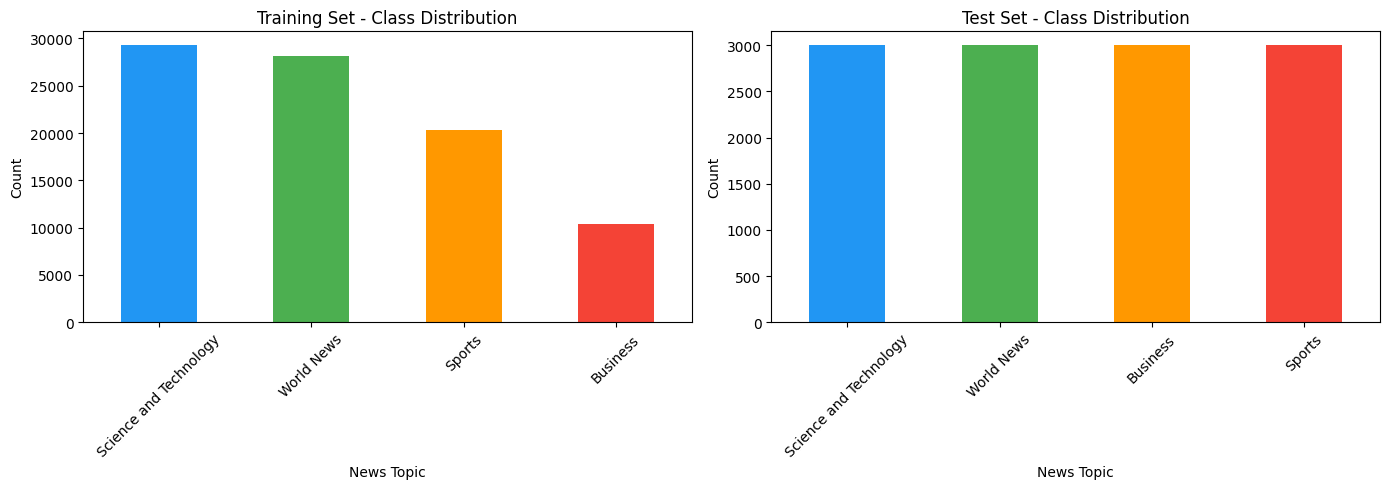

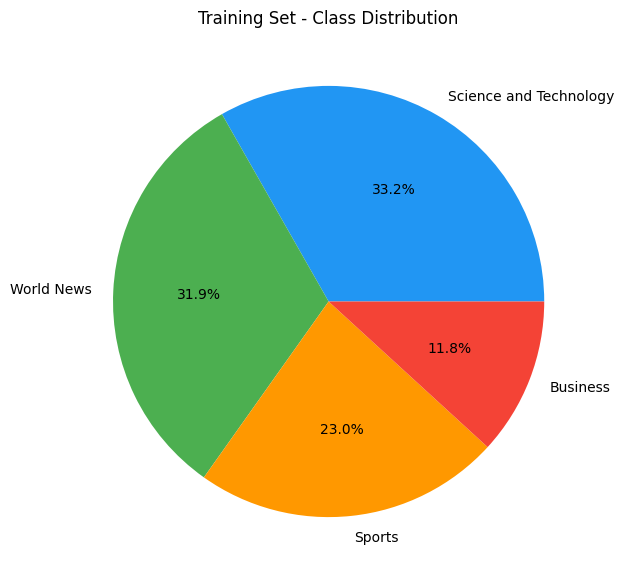

In [8]:
# Class distribution bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['News Topic'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
axes[0].set_title('Training Set - Class Distribution')
axes[0].set_xlabel('News Topic')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

test_df['News Topic'].value_counts().plot(kind='bar', ax=axes[1], color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
axes[1].set_title('Test Set - Class Distribution')
axes[1].set_xlabel('News Topic')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Pie chart
fig, ax = plt.subplots(figsize=(7, 7))
train_df['News Topic'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax,
    colors=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
ax.set_title('Training Set - Class Distribution')
ax.set_ylabel('')
plt.show()

### 3.2 Text Length Analysis

In [9]:
# Clean HTML tags for length analysis
def strip_html(text):
    return re.sub(r'<[^>]+>', '', str(text)).strip()

train_df['clean_text_temp'] = train_df['News Headline'].apply(strip_html)
train_df['text_length'] = train_df['clean_text_temp'].apply(len)
train_df['word_count'] = train_df['clean_text_temp'].apply(lambda x: len(x.split()))

print("Text Length Statistics:")
print(train_df[['text_length', 'word_count']].describe())

Text Length Statistics:
        text_length    word_count
count  88106.000000  88106.000000
mean     255.595975     39.921515
std       68.568748     10.627664
min      119.000000     10.000000
25%      214.000000     34.000000
50%      251.000000     39.000000
75%      286.000000     45.000000
max     1026.000000    173.000000


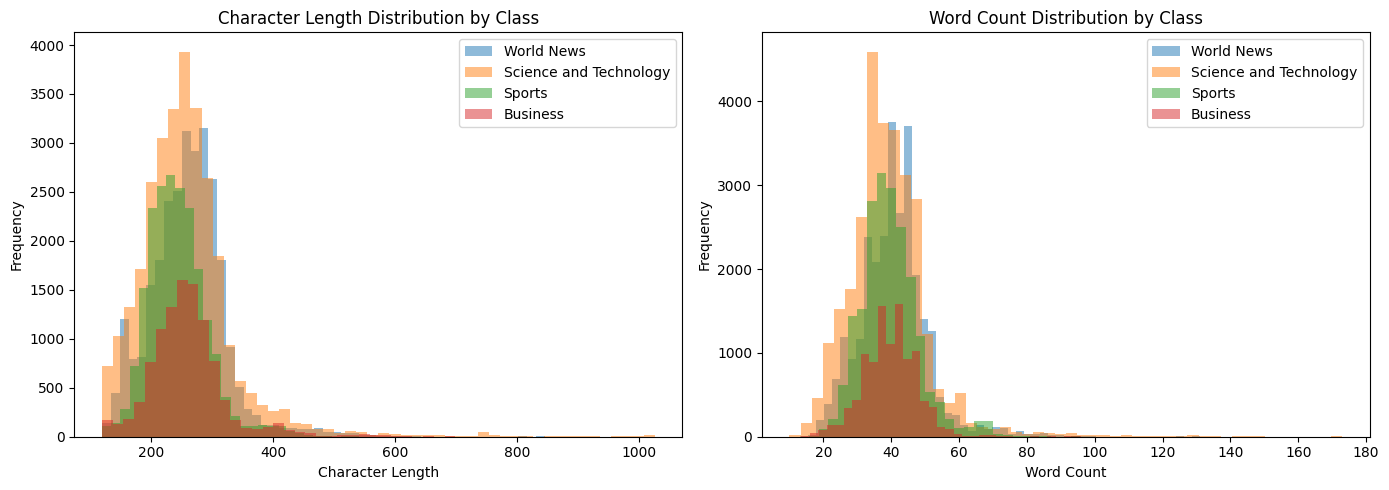

In [10]:
# Text length distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for topic in train_df['News Topic'].unique():
    subset = train_df[train_df['News Topic'] == topic]
    axes[0].hist(subset['text_length'], bins=50, alpha=0.5, label=topic)
    axes[1].hist(subset['word_count'], bins=50, alpha=0.5, label=topic)

axes[0].set_title('Character Length Distribution by Class')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Word Count Distribution by Class')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

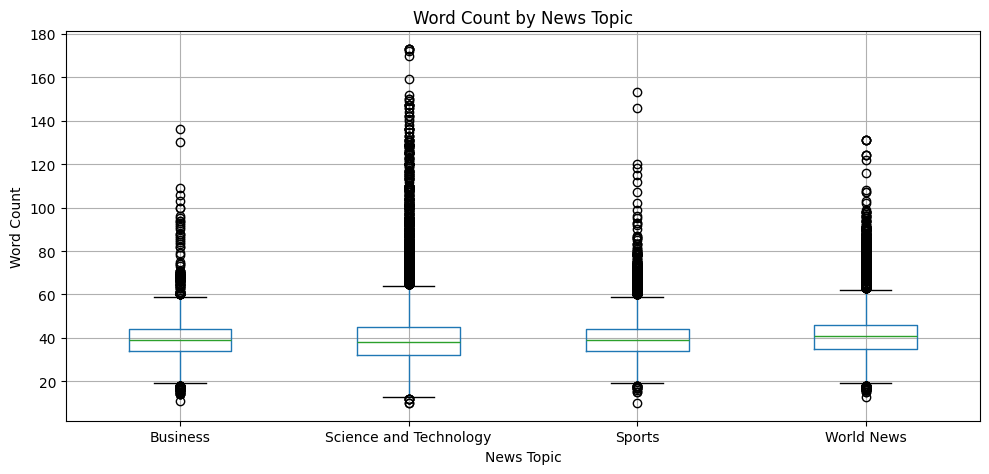

In [11]:
# Boxplot of word count per class
fig, ax = plt.subplots(figsize=(10, 5))
train_df.boxplot(column='word_count', by='News Topic', ax=ax)
ax.set_title('Word Count by News Topic')
ax.set_xlabel('News Topic')
ax.set_ylabel('Word Count')
plt.suptitle('')
plt.tight_layout()
plt.show()

### 3.3 Word Frequency Analysis

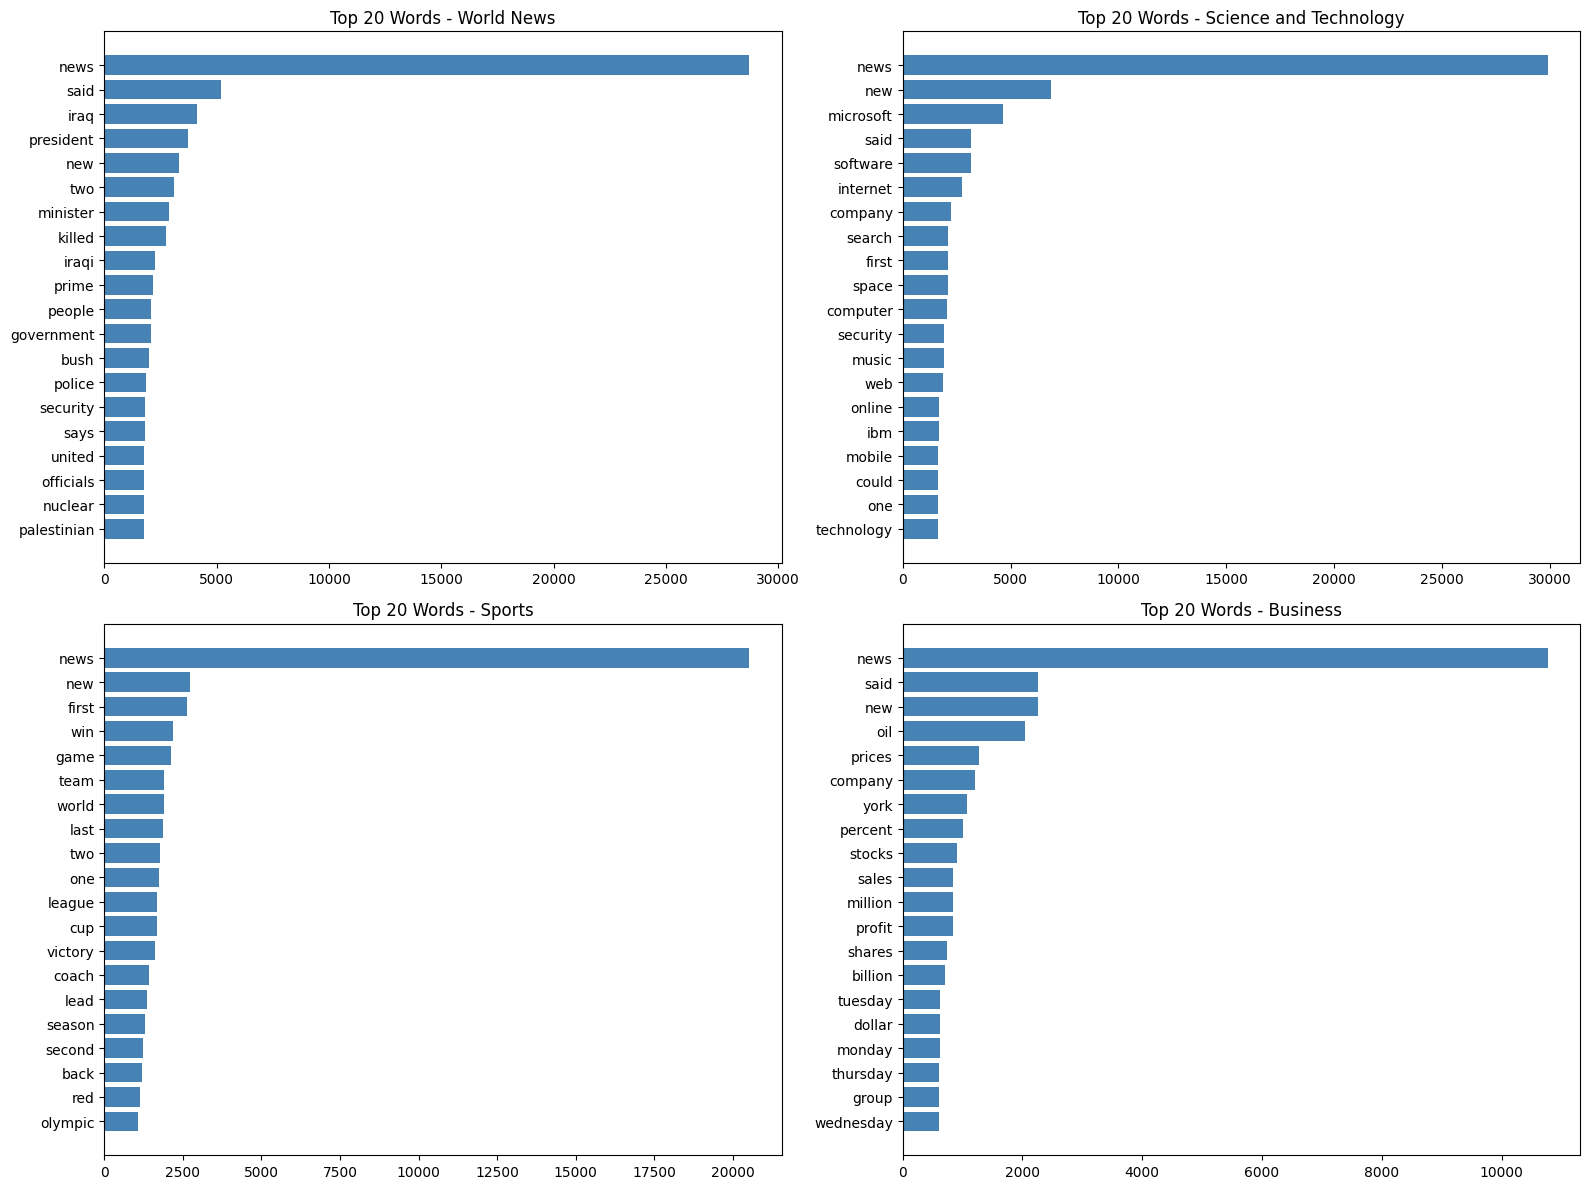

In [12]:
# Most common words per class (after basic cleaning)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
stop_words = set(stopwords.words('english'))

for idx, topic in enumerate(train_df['News Topic'].unique()):
    ax = axes[idx // 2][idx % 2]
    subset = train_df[train_df['News Topic'] == topic]['clean_text_temp']
    all_words = ' '.join(subset).lower().split()
    filtered_words = [w for w in all_words if w.isalpha() and w not in stop_words and len(w) > 2]
    word_freq = FreqDist(filtered_words)
    top_20 = word_freq.most_common(20)

    words = [w[0] for w in top_20]
    counts = [w[1] for w in top_20]
    ax.barh(words, counts, color='steelblue')
    ax.set_title(f'Top 20 Words - {topic}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 3.4 Word Clouds

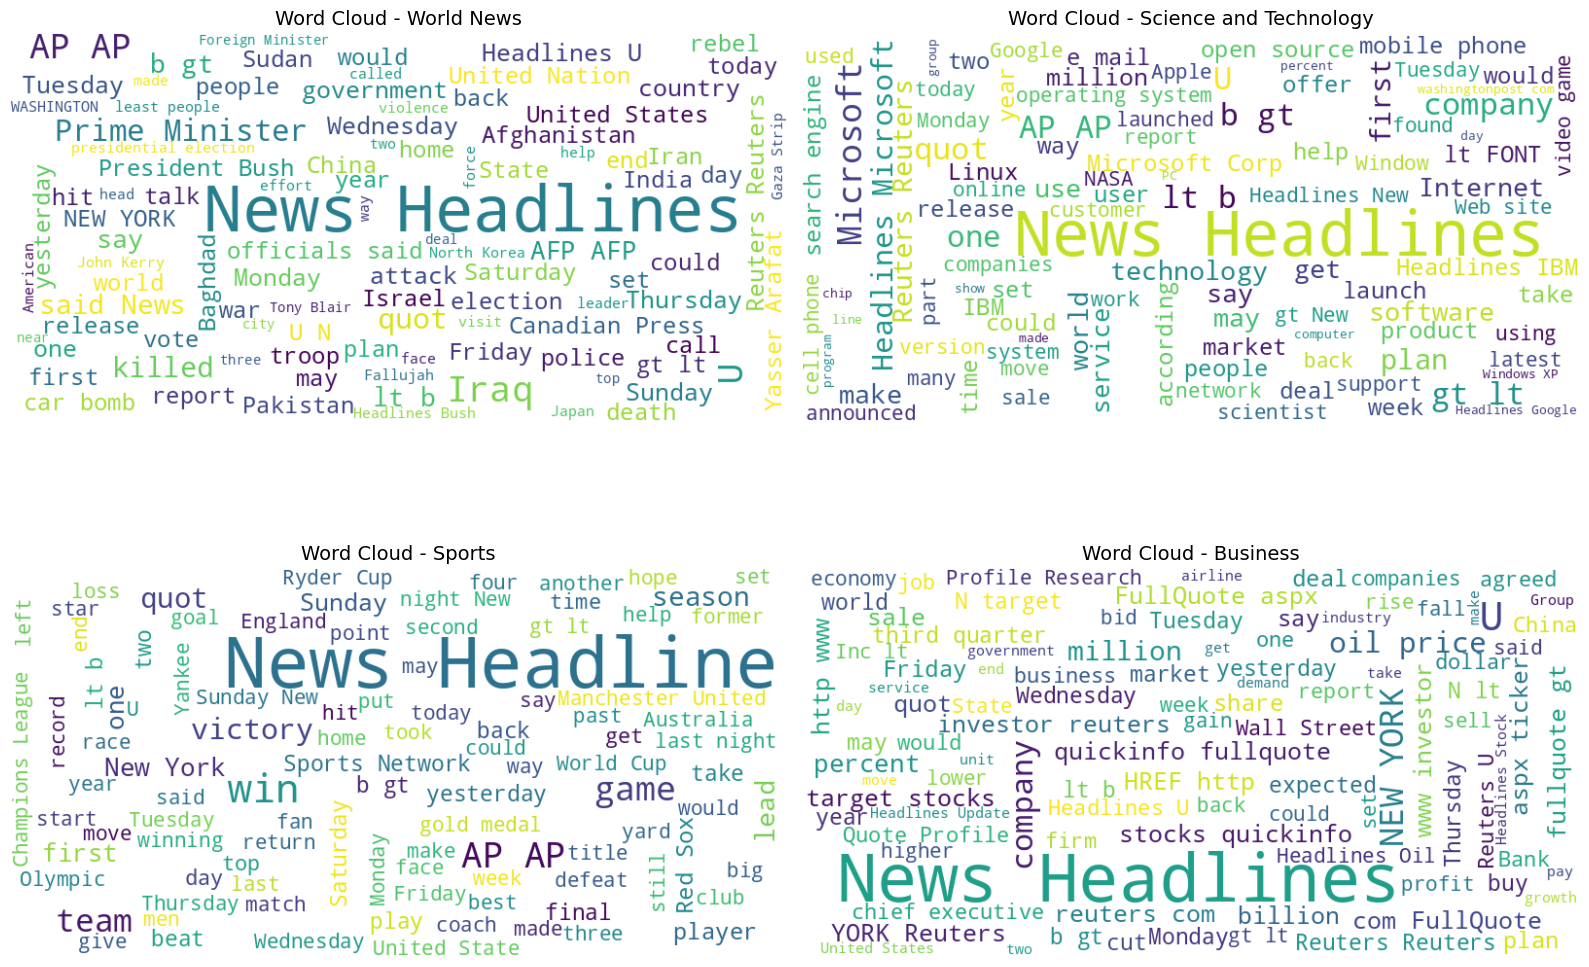

In [13]:
# Word cloud per class
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, topic in enumerate(train_df['News Topic'].unique()):
    ax = axes[idx // 2][idx % 2]
    subset = train_df[train_df['News Topic'] == topic]['clean_text_temp']
    text = ' '.join(subset)
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                         stopwords=stop_words, max_words=100).generate(text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'Word Cloud - {topic}', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3.5 N-gram Analysis

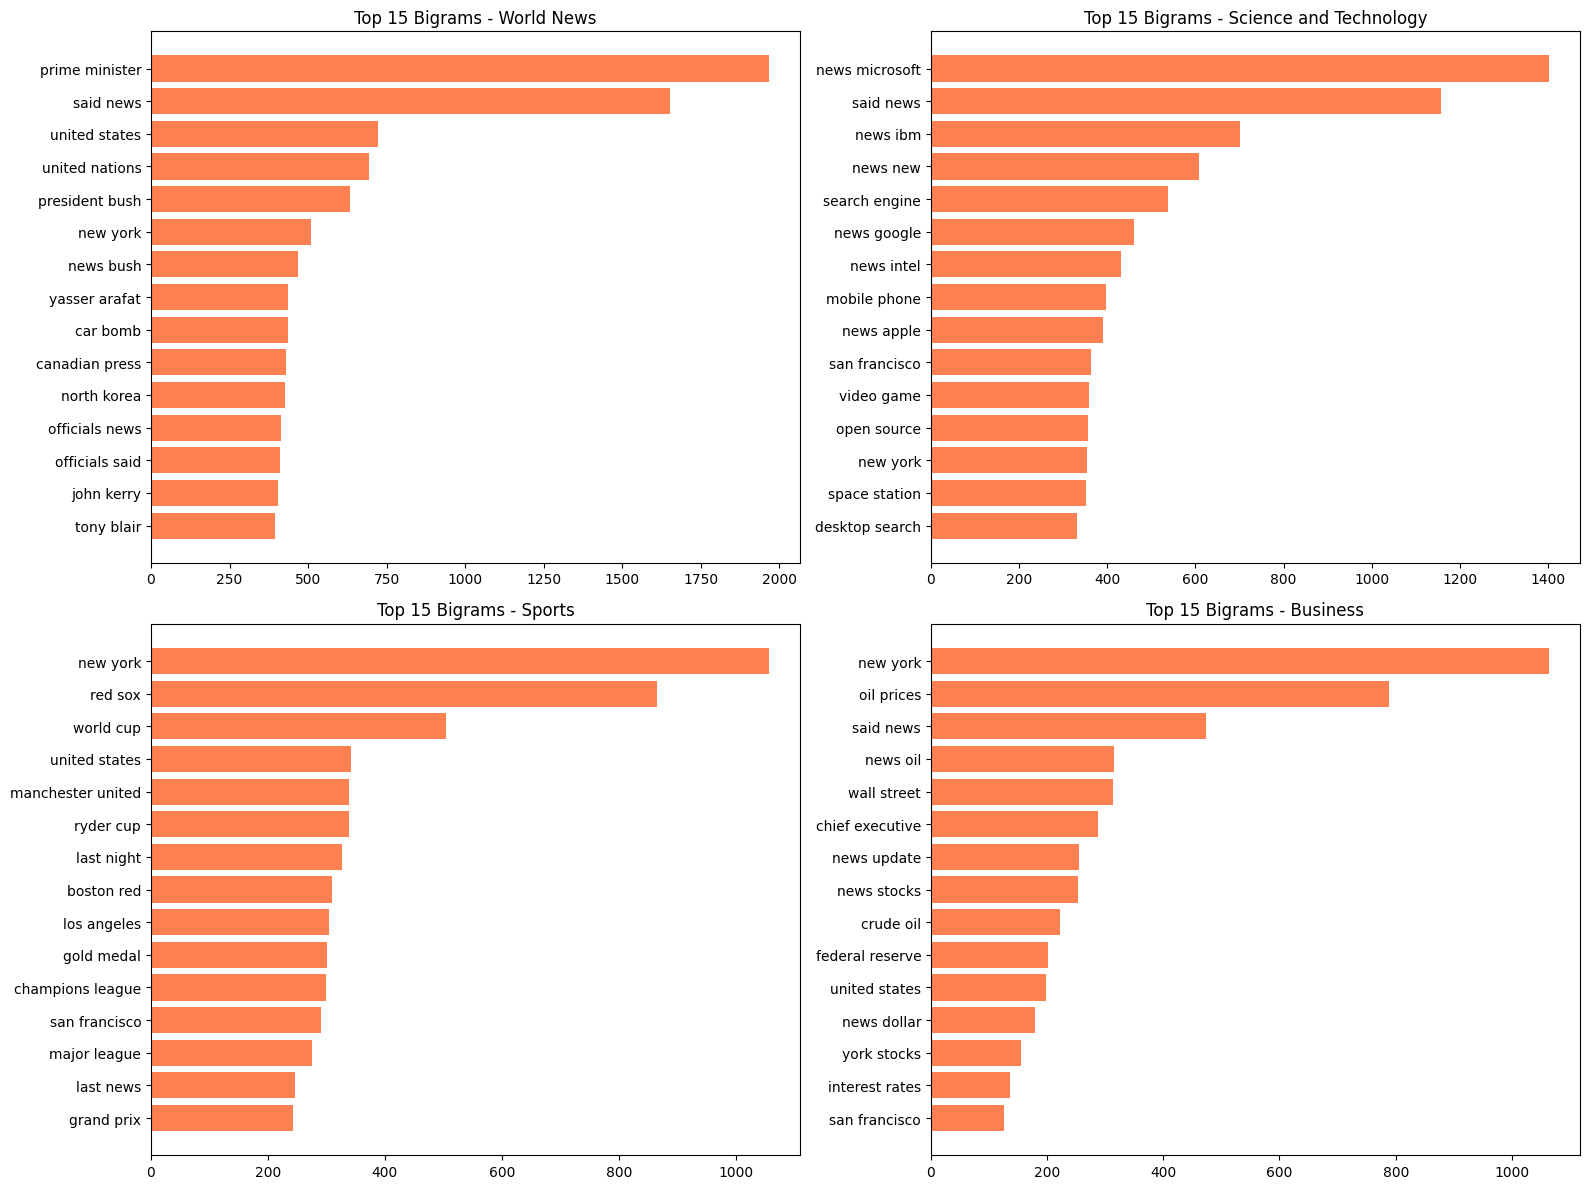

In [14]:
# Top bigrams per class
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, topic in enumerate(train_df['News Topic'].unique()):
    ax = axes[idx // 2][idx % 2]
    subset = train_df[train_df['News Topic'] == topic]['clean_text_temp']
    all_words = ' '.join(subset).lower().split()
    filtered = [w for w in all_words if w.isalpha() and w not in stop_words and len(w) > 2]
    bigram_list = list(ngrams(filtered, 2))
    bigram_freq = Counter(bigram_list).most_common(15)

    labels = [' '.join(bg[0]) for bg in bigram_freq]
    counts = [bg[1] for bg in bigram_freq]
    ax.barh(labels, counts, color='coral')
    ax.set_title(f'Top 15 Bigrams - {topic}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 3.6 EDA Findings Summary

**Key Observations:**
- The dataset has 4 classes: Science and Technology (~29K), World News (~28K), Sports (~20K), Business (~10K).
- There is class imbalance — Business has the fewest samples, roughly 1/3 of Science and Technology.
- The raw text contains HTML tags (`<html>`, `<body>`, `<br>`, `<b>`) that must be removed.
- Text lengths vary across classes; Sports headlines tend to be shorter.
- Each class has domain-specific vocabulary visible in word clouds and frequency plots.
- Bigram analysis reveals meaningful topic-specific phrases (e.g., "world cup" for Sports, "united states" for World News).
- Based on EDA, our optimum preprocessing will: remove HTML, lowercase, remove special characters, remove stopwords, and lemmatize — but NOT stem (stemming is too aggressive for this domain).

In [15]:
# Clean up temporary columns
train_df.drop(columns=['clean_text_temp', 'text_length', 'word_count'], inplace=True)

## 4. Text Preprocessing
We create three versions of the dataset with different levels of preprocessing:
1. **No preprocessing** — raw text as-is (only HTML tags stripped since they are markup, not content)
2. **Extreme preprocessing** — all techniques including stemming
3. **Optimum preprocessing** — based on EDA findings, balanced approach with lemmatization

### 4.1 Preprocessing Functions

In [16]:
# Label encoding
label_map = {'Business': 0, 'Science and Technology': 1, 'Sports': 2, 'World News': 3}
label_names = ['Business', 'Sci/Tech', 'Sports', 'World News']

train_df['label'] = train_df['News Topic'].map(label_map)
test_df['label'] = test_df['News Topic'].map(label_map)

print("Label mapping:", label_map)

Label mapping: {'Business': 0, 'Science and Technology': 1, 'Sports': 2, 'World News': 3}


In [17]:
# Preprocessing functions
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words_set = set(stopwords.words('english'))

def preprocess_none(text):
    # Only strip HTML tags (they are markup, not actual text content)
    text = re.sub(r'<[^>]+>', '', str(text))
    text = text.strip()
    return text

def preprocess_extreme(text):
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', str(text))
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words_set and len(t) > 1]
    # Stemming (aggressive)
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

def preprocess_optimum(text):
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', str(text))
    # Lowercase
    text = text.lower()
    # Remove special characters but keep numbers (can be meaningful in news)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words_set and len(t) > 1]
    # Lemmatize (less aggressive than stemming, preserves meaning)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print("Preprocessing functions defined.")

Preprocessing functions defined.


### 4.2 Apply Preprocessing

In [18]:
# Apply all three preprocessing variants
print("Applying preprocessing... (this may take a few minutes on 88K samples)")

# No preprocessing
train_df['text_none'] = train_df['News Headline'].apply(preprocess_none)
test_df['text_none'] = test_df['News Headline'].apply(preprocess_none)
print("No preprocessing done.")

# Extreme preprocessing
train_df['text_extreme'] = train_df['News Headline'].apply(preprocess_extreme)
test_df['text_extreme'] = test_df['News Headline'].apply(preprocess_extreme)
print("Extreme preprocessing done.")

# Optimum preprocessing
train_df['text_optimum'] = train_df['News Headline'].apply(preprocess_optimum)
test_df['text_optimum'] = test_df['News Headline'].apply(preprocess_optimum)
print("Optimum preprocessing done.")

# Display samples
print("\n--- Sample Comparison ---")
for i in [0, 100, 500]:
    print(f"\nOriginal:  {train_df['News Headline'].iloc[i][:150]}")
    print(f"None:      {train_df['text_none'].iloc[i][:150]}")
    print(f"Extreme:   {train_df['text_extreme'].iloc[i][:150]}")
    print(f"Optimum:   {train_df['text_optimum'].iloc[i][:150]}")

Applying preprocessing... (this may take a few minutes on 88K samples)
No preprocessing done.
Extreme preprocessing done.
Optimum preprocessing done.

--- Sample Comparison ---

Original:  <html> <body> News Headlines:
 <br> <b> 13 dead, 52 wounded in Philippine bomb explosion COTABATO, Philippines: Thirteen people were killed and at lea
None:      News Headlines:
   13 dead, 52 wounded in Philippine bomb explosion COTABATO, Philippines: Thirteen people were killed and at least 52 others injured 
Extreme:   news headlin dead wound philippin bomb explos cotabato philippin thirteen peopl kill least other injur bomb attack public market southern philippin su
Optimum:   news headline 13 dead 52 wounded philippine bomb explosion cotabato philippine thirteen people killed least 52 others injured bomb attack public marke

Original:  <html> <body> News Headlines:
 <br> <b> CELL Prototype Announced By Sony, Toshiba, and IBM In two joint press releases, Sony Corporation, Sony Compute
None:      

In [19]:
# Vocabulary size comparison after preprocessing
for prep_name, col in [('No Preprocessing', 'text_none'), ('Extreme', 'text_extreme'), ('Optimum', 'text_optimum')]:
    all_words = ' '.join(train_df[col]).split()
    vocab_size = len(set(all_words))
    avg_len = np.mean([len(t.split()) for t in train_df[col]])
    print(f"{prep_name}: Vocabulary Size = {vocab_size}, Avg Words/Doc = {avg_len:.1f}")

No Preprocessing: Vocabulary Size = 137677, Avg Words/Doc = 39.9
Extreme: Vocabulary Size = 51753, Avg Words/Doc = 26.7
Optimum: Vocabulary Size = 69875, Avg Words/Doc = 27.6


### 4.3 Train-Validation Split

In [20]:
# Split training data into train and validation (80/20)
y_train_full = train_df['label'].values
y_test = test_df['label'].values

X_train_none, X_val_none, y_train, y_val = train_test_split(
    train_df['text_none'].values, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)
X_train_extreme, X_val_extreme, _, _ = train_test_split(
    train_df['text_extreme'].values, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)
X_train_optimum, X_val_optimum, _, _ = train_test_split(
    train_df['text_optimum'].values, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

X_test_none = test_df['text_none'].values
X_test_extreme = test_df['text_extreme'].values
X_test_optimum = test_df['text_optimum'].values

print(f"Train: {len(X_train_none)}, Validation: {len(X_val_none)}, Test: {len(X_test_none)}")
print(f"Train label distribution: {np.bincount(y_train)}")
print(f"Val label distribution: {np.bincount(y_val)}")
print(f"Test label distribution: {np.bincount(y_test)}")

Train: 70484, Validation: 17622, Test: 12000
Train label distribution: [ 8316 23428 16225 22515]
Val label distribution: [2079 5858 4056 5629]
Test label distribution: [3000 3000 3000 3000]


## 5. Evaluation Helper Functions
We define reusable functions for evaluation metrics and visualization.

In [21]:
# Store all results
all_results = []

def evaluate_model(model_name, preprocessing, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n{'='*60}")
    print(f"Model: {model_name} | Preprocessing: {preprocessing}")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (macro): {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix: {model_name} ({preprocessing})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    all_results.append({
        'Model': model_name,
        'Preprocessing': preprocessing,
        'Accuracy': acc,
        'F1-Score': f1
    })

    return acc, f1

def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

print("Evaluation functions defined.")

Evaluation functions defined.


## 5.5 Hyperparameter Tuning
We manually tune hyperparameters for each model family using the **Optimum Preprocessing** variant (our best preprocessing based on EDA). We compare validation performance across different settings and select the best configuration for the final 24 training runs.

### 5.5.1 Logistic Regression — Tuning Regularization (C)

In [22]:
# Build TF-IDF vectors for tuning (needed before section 6)
tfidf_vectorizer_optimum = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf_optimum = tfidf_vectorizer_optimum.fit_transform(X_train_optimum)
X_val_tfidf_optimum = tfidf_vectorizer_optimum.transform(X_val_optimum)
X_test_tfidf_optimum = tfidf_vectorizer_optimum.transform(X_test_optimum)

print(f"TF-IDF (Optimum) matrix shape: {X_train_tfidf_optimum.shape}")

TF-IDF (Optimum) matrix shape: (70484, 50000)


In [23]:
# Logistic Regression: Tune regularization parameter C
# C controls the inverse of regularization strength:
#   - Small C = strong regularization (simpler model, may underfit)
#   - Large C = weak regularization (complex model, may overfit)

C_values = [0.01, 0.1, 1.0, 5.0, 10.0]
lr_tuning_results = []

for c_val in C_values:
    lr_temp = LogisticRegression(max_iter=1000, C=c_val, solver='lbfgs',
                                  multi_class='multinomial', random_state=42)
    lr_temp.fit(X_train_tfidf_optimum, y_train)
    y_val_pred = lr_temp.predict(X_val_tfidf_optimum)

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average='macro')
    lr_tuning_results.append({'C': c_val, 'Val Accuracy': acc, 'Val F1': f1})
    print(f"C={c_val:<6} → Val Accuracy: {acc:.4f}, Val F1: {f1:.4f}")

lr_tune_df = pd.DataFrame(lr_tuning_results)
best_C = lr_tune_df.loc[lr_tune_df['Val F1'].idxmax(), 'C']
print(f"\nBest C = {best_C}")

C=0.01   → Val Accuracy: 0.8140, Val F1: 0.6814
C=0.1    → Val Accuracy: 0.9098, Val F1: 0.8846
C=1.0    → Val Accuracy: 0.9366, Val F1: 0.9213
C=5.0    → Val Accuracy: 0.9486, Val F1: 0.9353
C=10.0   → Val Accuracy: 0.9499, Val F1: 0.9374

Best C = 10.0


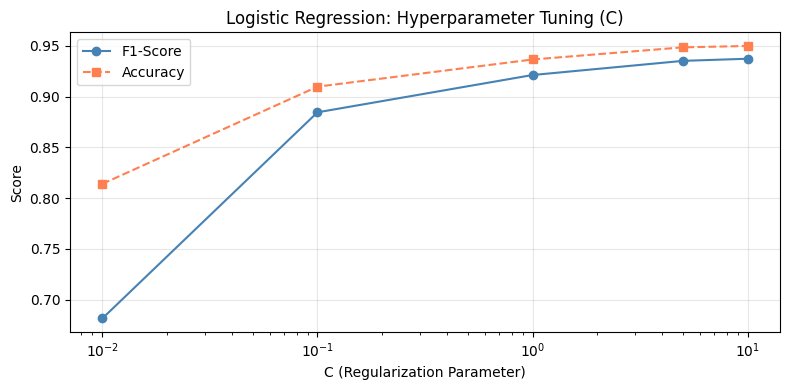

Selected C = 10.0 for all Logistic Regression runs.


In [24]:
# Visualize LR tuning results
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lr_tune_df['C'], lr_tune_df['Val F1'], 'o-', label='F1-Score', color='steelblue')
ax.plot(lr_tune_df['C'], lr_tune_df['Val Accuracy'], 's--', label='Accuracy', color='coral')
ax.set_xscale('log')
ax.set_xlabel('C (Regularization Parameter)')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression: Hyperparameter Tuning (C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Selected C = {best_C} for all Logistic Regression runs.")

### 5.5.2 Deep Neural Network — Tuning Architecture and Dropout
We experiment with different layer configurations and dropout rates. All DNN variants use TF-IDF (10,000 features) with Adam optimizer.

In [25]:
# DNN: Prepare reduced TF-IDF for tuning (10K features to avoid MemoryError)
tfidf_dnn_tune = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_dnn_tune = tfidf_dnn_tune.fit_transform(X_train_optimum).astype('float32').toarray()
X_val_dnn_tune = tfidf_dnn_tune.transform(X_val_optimum).astype('float32').toarray()

y_train_cat_tune = to_categorical(y_train, num_classes=4)
y_val_cat_tune = to_categorical(y_val, num_classes=4)

print(f"DNN tuning data shape: {X_train_dnn_tune.shape}")

DNN tuning data shape: (70484, 5000)


In [26]:
# DNN Configuration 1: Smaller network, moderate dropout
# Architecture: 128 → 64 → 32 → 4, dropout=0.3
dnn_config1 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_dnn_tune.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])
dnn_config1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

h1 = dnn_config1.fit(X_train_dnn_tune, y_train_cat_tune, epochs=15, batch_size=256,
                      validation_data=(X_val_dnn_tune, y_val_cat_tune),
                      callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
                      verbose=1)
val_acc1 = max(h1.history['val_accuracy'])
print(f"\nConfig 1 (128→64→32, drop=0.3): Best Val Accuracy = {val_acc1:.4f}")
del dnn_config1; import gc; gc.collect()

Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8236 - loss: 0.4724 - val_accuracy: 0.9249 - val_loss: 0.2288
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9338 - loss: 0.2053 - val_accuracy: 0.9304 - val_loss: 0.2138
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9492 - loss: 0.1541 - val_accuracy: 0.9342 - val_loss: 0.2129
Epoch 4/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9629 - loss: 0.1167 - val_accuracy: 0.9369 - val_loss: 0.2211
Epoch 5/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9727 - loss: 0.0870 - val_accuracy: 0.9384 - val_loss: 0.2353
Epoch 6/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9803 - loss: 0.0630 - val_accuracy: 0.9413 - val_loss: 0.2562

Config 1 (128→64→32, drop=0.3): Best Val Accuracy = 0.9413


774

In [27]:
# DNN Configuration 2: Wider network, higher dropout
# Architecture: 256 → 128 → 64 → 32 → 4, dropout=0.3/0.2
dnn_config2 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_dnn_tune.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])
dnn_config2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

h2 = dnn_config2.fit(X_train_dnn_tune, y_train_cat_tune, epochs=15, batch_size=256,
                      validation_data=(X_val_dnn_tune, y_val_cat_tune),
                      callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
                      verbose=1)
val_acc2 = max(h2.history['val_accuracy'])
print(f"\nConfig 2 (256→128→64→32, drop=0.3/0.2): Best Val Accuracy = {val_acc2:.4f}")
del dnn_config2; import gc; gc.collect()

Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8370 - loss: 0.4322 - val_accuracy: 0.9271 - val_loss: 0.2230
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9399 - loss: 0.1885 - val_accuracy: 0.9345 - val_loss: 0.2149
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9602 - loss: 0.1285 - val_accuracy: 0.9353 - val_loss: 0.2205
Epoch 4/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9735 - loss: 0.0854 - val_accuracy: 0.9398 - val_loss: 0.2309
Epoch 5/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9834 - loss: 0.0541 - val_accuracy: 0.9427 - val_loss: 0.2635

Config 2 (256→128→64→32, drop=0.3/0.2): Best Val Accuracy = 0.9427


712

In [28]:
# DNN Configuration 3: Wider network, aggressive dropout
# Architecture: 512 → 256 → 128 → 64 → 4, dropout=0.5/0.3
dnn_config3 = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_dnn_tune.shape[1],)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])
dnn_config3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

h3 = dnn_config3.fit(X_train_dnn_tune, y_train_cat_tune, epochs=15, batch_size=256,
                      validation_data=(X_val_dnn_tune, y_val_cat_tune),
                      callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
                      verbose=1)
val_acc3 = max(h3.history['val_accuracy'])
print(f"\nConfig 3 (512→256→128→64, drop=0.5/0.3): Best Val Accuracy = {val_acc3:.4f}")
del dnn_config3; import gc; gc.collect()

Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8384 - loss: 0.4272 - val_accuracy: 0.9259 - val_loss: 0.2273
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9419 - loss: 0.1826 - val_accuracy: 0.9347 - val_loss: 0.2046
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9639 - loss: 0.1172 - val_accuracy: 0.9387 - val_loss: 0.2114
Epoch 4/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9773 - loss: 0.0747 - val_accuracy: 0.9416 - val_loss: 0.2262
Epoch 5/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9842 - loss: 0.0501 - val_accuracy: 0.9433 - val_loss: 0.2408

Config 3 (512→256→128→64, drop=0.5/0.3): Best Val Accuracy = 0.9433


712

DNN Hyperparameter Tuning Results:
  Config 1 (128→64→32, drop=0.3): Val Accuracy = 0.9413
  Config 2 (256→128→64→32, drop=0.3/0.2): Val Accuracy = 0.9427
  Config 3 (512→256→128→64, drop=0.5/0.3): Val Accuracy = 0.9433

Best DNN Config: Config 3 (512→256→128→64, drop=0.5/0.3)
This configuration will be used for all 3 preprocessing variants.


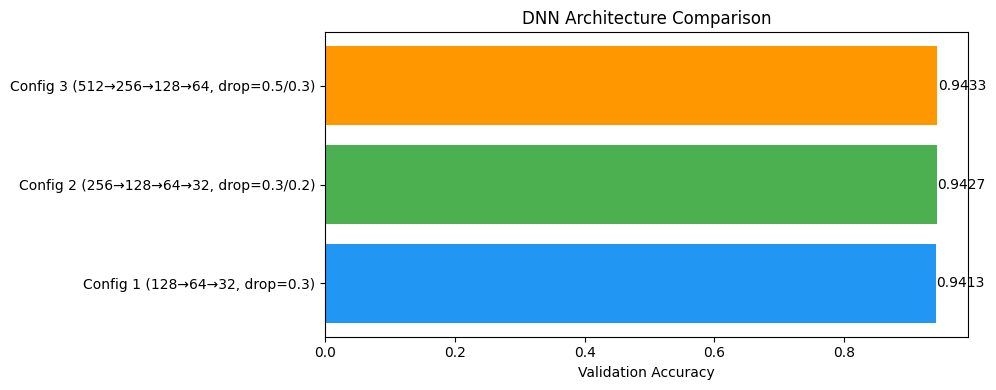

9649

In [29]:
# DNN: Compare all configurations and select best
dnn_configs = {
    'Config 1 (128→64→32, drop=0.3)': {'val_acc': val_acc1, 'layers': [128,64,32], 'dropouts': [0.3,0.3]},
    'Config 2 (256→128→64→32, drop=0.3/0.2)': {'val_acc': val_acc2, 'layers': [256,128,64,32], 'dropouts': [0.3,0.3,0.2]},
    'Config 3 (512→256→128→64, drop=0.5/0.3)': {'val_acc': val_acc3, 'layers': [512,256,128,64], 'dropouts': [0.5,0.3,0.3]},
}

print("DNN Hyperparameter Tuning Results:")
print("="*60)
for name, info in dnn_configs.items():
    print(f"  {name}: Val Accuracy = {info['val_acc']:.4f}")

best_dnn = max(dnn_configs, key=lambda k: dnn_configs[k]['val_acc'])
print(f"\nBest DNN Config: {best_dnn}")
print("This configuration will be used for all 3 preprocessing variants.")

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
names = list(dnn_configs.keys())
accs = [dnn_configs[n]['val_acc'] for n in names]
bars = ax.barh(names, accs, color=['#2196F3', '#4CAF50', '#FF9800'])
ax.set_xlabel('Validation Accuracy')
ax.set_title('DNN Architecture Comparison')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f'{acc:.4f}', va='center')
plt.tight_layout()
plt.show()

# Free tuning data
del X_train_dnn_tune, X_val_dnn_tune, y_train_cat_tune, y_val_cat_tune
import gc; gc.collect()

### 5.5.3 Deep Neural Network — Tuning Batch Size

In [30]:
# DNN: Tune batch size using the best architecture found above
# Re-create tuning data
tfidf_dnn_tune = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_dnn_tune = tfidf_dnn_tune.fit_transform(X_train_optimum).astype('float32').toarray()
X_val_dnn_tune = tfidf_dnn_tune.transform(X_val_optimum).astype('float32').toarray()
y_train_cat_tune = to_categorical(y_train, num_classes=4)
y_val_cat_tune = to_categorical(y_val, num_classes=4)

batch_sizes = [64, 128, 256, 512]
batch_results = []

for bs in batch_sizes:
    # Use best architecture from previous tuning (Config 2 as default)
    model_bs = Sequential([
        Dense(256, activation='relu', input_shape=(X_train_dnn_tune.shape[1],)),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(4, activation='softmax')
    ])
    model_bs.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    h = model_bs.fit(X_train_dnn_tune, y_train_cat_tune, epochs=15, batch_size=bs,
                     validation_data=(X_val_dnn_tune, y_val_cat_tune),
                     callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
                     verbose=0)
    best_val = max(h.history['val_accuracy'])
    batch_results.append({'Batch Size': bs, 'Val Accuracy': best_val})
    print(f"Batch Size={bs:<4} → Best Val Accuracy: {best_val:.4f}")

batch_df = pd.DataFrame(batch_results)
best_batch = int(batch_df.loc[batch_df['Val Accuracy'].idxmax(), 'Batch Size'])
print(f"\nBest Batch Size = {best_batch}")

# Free memory
del X_train_dnn_tune, X_val_dnn_tune, y_train_cat_tune, y_val_cat_tune, model_bs
import gc; gc.collect()

Batch Size=64   → Best Val Accuracy: 0.9431
Batch Size=128  → Best Val Accuracy: 0.9419
Batch Size=256  → Best Val Accuracy: 0.9407
Batch Size=512  → Best Val Accuracy: 0.9398

Best Batch Size = 64


14894

### 5.5.4 RNN Models — Tuning Units and Dropout
We tune the number of recurrent units and dropout rate using LSTM on Optimum Preprocessing (findings apply to all RNN variants).

In [31]:
# Build Skip-gram embeddings and tokenized sequences for tuning (needed before section 8)
from gensim.models import Word2Vec

NUM_WORDS = 20000
MAX_LEN = 100
EMBED_DIM = 100

tokenizer_data = {}
embedding_matrices = {}

for prep_label, prep_key in [('No Preprocessing', 'none'), ('Extreme', 'extreme'), ('Optimum', 'optimum')]:
    # Keras Tokenizer
    tok = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
    X_tr = X_train_none if prep_key == 'none' else (X_train_extreme if prep_key == 'extreme' else X_train_optimum)
    X_v = X_val_none if prep_key == 'none' else (X_val_extreme if prep_key == 'extreme' else X_val_optimum)
    X_te = X_test_none if prep_key == 'none' else (X_test_extreme if prep_key == 'extreme' else X_test_optimum)

    tok.fit_on_texts(X_tr)
    X_tr_seq = pad_sequences(tok.texts_to_sequences(X_tr), maxlen=MAX_LEN, padding='post')
    X_v_seq = pad_sequences(tok.texts_to_sequences(X_v), maxlen=MAX_LEN, padding='post')
    X_te_seq = pad_sequences(tok.texts_to_sequences(X_te), maxlen=MAX_LEN, padding='post')

    tokenizer_data[prep_key] = {
        'tokenizer': tok,
        'X_train_seq': X_tr_seq,
        'X_val_seq': X_v_seq,
        'X_test_seq': X_te_seq
    }

    # Train Skip-gram
    sentences = [text.split() for text in X_tr]
    w2v_model = Word2Vec(sentences=sentences, vector_size=EMBED_DIM, window=5,
                         sg=1, min_count=2, workers=4, epochs=10)

    word_index = tok.word_index
    vocab_size = min(NUM_WORDS, len(word_index) + 1)
    embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
    found = 0
    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
            found += 1
    embedding_matrices[prep_key] = embedding_matrix
    print(f"{prep_label}: vocab={vocab_size}, Skip-gram matches={found}, seq shape={X_tr_seq.shape}")

print('\nTokenization and Skip-gram embeddings ready for all variants.')

No Preprocessing: vocab=20000, Skip-gram matches=13935, seq shape=(70484, 100)
Extreme: vocab=20000, Skip-gram matches=19998, seq shape=(70484, 100)
Optimum: vocab=20000, Skip-gram matches=19998, seq shape=(70484, 100)

Tokenization and Skip-gram embeddings ready for all variants.


In [32]:
# RNN Tuning: Use LSTM as representative model on optimum preprocessing
# Tune: recurrent units and dropout rate
td_tune = tokenizer_data['optimum']

rnn_tuning_results = []

unit_dropout_combos = [
    (32, 0.3),
    (32, 0.5),
    (64, 0.3),
    (64, 0.5),
    (128, 0.3),
    (128, 0.5),
]

for units, drop in unit_dropout_combos:
    vocab_size = embedding_matrices['optimum'].shape[0]

    rnn_tune_model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
                  weights=[embedding_matrices['optimum']], trainable=True),
        LSTM(units),
        Dropout(drop),
        Dense(4, activation='softmax')
    ])
    rnn_tune_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    h = rnn_tune_model.fit(
        td_tune['X_train_seq'], y_train,
        epochs=10, batch_size=128,
        validation_data=(td_tune['X_val_seq'], y_val),
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=0
    )
    best_val = max(h.history['val_accuracy'])
    rnn_tuning_results.append({'Units': units, 'Dropout': drop, 'Val Accuracy': best_val})
    print(f"LSTM(units={units}, dropout={drop}) → Best Val Accuracy: {best_val:.4f}")

    del rnn_tune_model
    import gc; gc.collect()

rnn_tune_df = pd.DataFrame(rnn_tuning_results)
best_rnn_row = rnn_tune_df.loc[rnn_tune_df['Val Accuracy'].idxmax()]
best_rnn_units = int(best_rnn_row['Units'])
best_rnn_dropout = best_rnn_row['Dropout']
print(f"\nBest RNN Config: units={best_rnn_units}, dropout={best_rnn_dropout}")

LSTM(units=32, dropout=0.3) → Best Val Accuracy: 0.3324
LSTM(units=32, dropout=0.5) → Best Val Accuracy: 0.3324
LSTM(units=64, dropout=0.3) → Best Val Accuracy: 0.3324
LSTM(units=64, dropout=0.5) → Best Val Accuracy: 0.6998
LSTM(units=128, dropout=0.3) → Best Val Accuracy: 0.9427
LSTM(units=128, dropout=0.5) → Best Val Accuracy: 0.3324

Best RNN Config: units=128, dropout=0.3


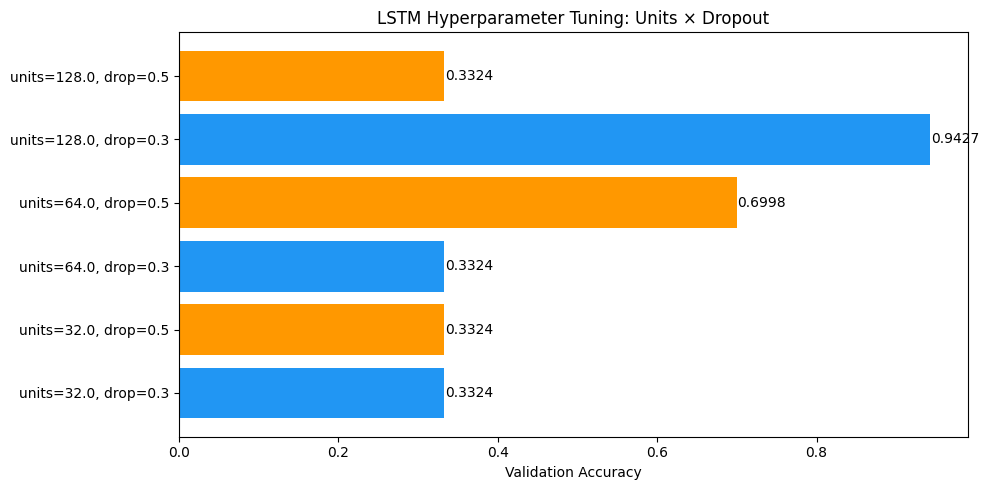

In [33]:
# Visualize RNN tuning results
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"units={r['Units']}, drop={r['Dropout']}" for _, r in rnn_tune_df.iterrows()]
colors_list = ['#2196F3' if r['Dropout']==0.3 else '#FF9800' for _, r in rnn_tune_df.iterrows()]
bars = ax.barh(labels, rnn_tune_df['Val Accuracy'], color=colors_list)
ax.set_xlabel('Validation Accuracy')
ax.set_title('LSTM Hyperparameter Tuning: Units × Dropout')
for bar, acc in zip(bars, rnn_tune_df['Val Accuracy']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f'{acc:.4f}', va='center')
plt.tight_layout()
plt.show()

### 5.5.5 RNN Models — Tuning Batch Size

In [34]:
# RNN: Tune batch size using best units/dropout from above
rnn_batch_results = []

for bs in [64, 128, 256]:
    vocab_size = embedding_matrices['optimum'].shape[0]
    rnn_bs_model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
                  weights=[embedding_matrices['optimum']], trainable=True),
        LSTM(best_rnn_units),
        Dropout(best_rnn_dropout),
        Dense(4, activation='softmax')
    ])
    rnn_bs_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    h = rnn_bs_model.fit(
        td_tune['X_train_seq'], y_train,
        epochs=10, batch_size=bs,
        validation_data=(td_tune['X_val_seq'], y_val),
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=0
    )
    best_val = max(h.history['val_accuracy'])
    rnn_batch_results.append({'Batch Size': bs, 'Val Accuracy': best_val})
    print(f"Batch Size={bs:<4} → Best Val Accuracy: {best_val:.4f}")

    del rnn_bs_model
    import gc; gc.collect()

rnn_batch_df = pd.DataFrame(rnn_batch_results)
best_rnn_batch = int(rnn_batch_df.loc[rnn_batch_df['Val Accuracy'].idxmax(), 'Batch Size'])
print(f"\nBest RNN Batch Size = {best_rnn_batch}")

Batch Size=64   → Best Val Accuracy: 0.3324
Batch Size=128  → Best Val Accuracy: 0.3324
Batch Size=256  → Best Val Accuracy: 0.3324

Best RNN Batch Size = 64


### 5.5.6 Hyperparameter Tuning Summary

In [35]:
# Final summary of selected hyperparameters
print("="*60)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*60)
print(f"\nLogistic Regression:")
print(f"  C = {best_C}, solver = lbfgs, max_iter = 1000")
print(f"\nDeep Neural Network:")
print(f"  Best architecture: {best_dnn}")
print(f"  Batch size: {best_batch}")
print(f"  Optimizer: Adam, Early stopping patience: 3")
print(f"\nRNN Models (SimpleRNN, GRU, LSTM, + Bidirectional):")
print(f"  Units: {best_rnn_units}")
print(f"  Dropout: {best_rnn_dropout}")
print(f"  Batch size: {best_rnn_batch}")
print(f"  Embedding dim: {EMBED_DIM}, Max sequence length: {MAX_LEN}")
print(f"  Optimizer: Adam, Early stopping patience: 3")
print(f"\nThese settings will be applied to all 24 training runs below.")
print("="*60)

HYPERPARAMETER TUNING SUMMARY

Logistic Regression:
  C = 10.0, solver = lbfgs, max_iter = 1000

Deep Neural Network:
  Best architecture: Config 3 (512→256→128→64, drop=0.5/0.3)
  Batch size: 64
  Optimizer: Adam, Early stopping patience: 3

RNN Models (SimpleRNN, GRU, LSTM, + Bidirectional):
  Units: 128
  Dropout: 0.3
  Batch size: 64
  Embedding dim: 100, Max sequence length: 100
  Optimizer: Adam, Early stopping patience: 3

These settings will be applied to all 24 training runs below.


## 6. TF-IDF + Logistic Regression
We train Logistic Regression using TF-IDF vectors for all three preprocessing variants.

In [36]:
# Re-import essentials (safe to re-run if runtime restarted)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, gc, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

### 6.1 TF-IDF + Logistic Regression — No Preprocessing

TF-IDF matrix shape (train): (70484, 50000)

--- Validation Set ---

Model: TF-IDF + Logistic Regression | Preprocessing: No Preprocessing
Accuracy: 0.9489
F1-Score (macro): 0.9354

Classification Report:
              precision    recall  f1-score   support

    Business       0.91      0.80      0.86      2079
    Sci/Tech       0.94      0.97      0.95      5858
      Sports       0.97      0.98      0.98      4056
  World News       0.96      0.96      0.96      5629

    accuracy                           0.95     17622
   macro avg       0.94      0.93      0.94     17622
weighted avg       0.95      0.95      0.95     17622



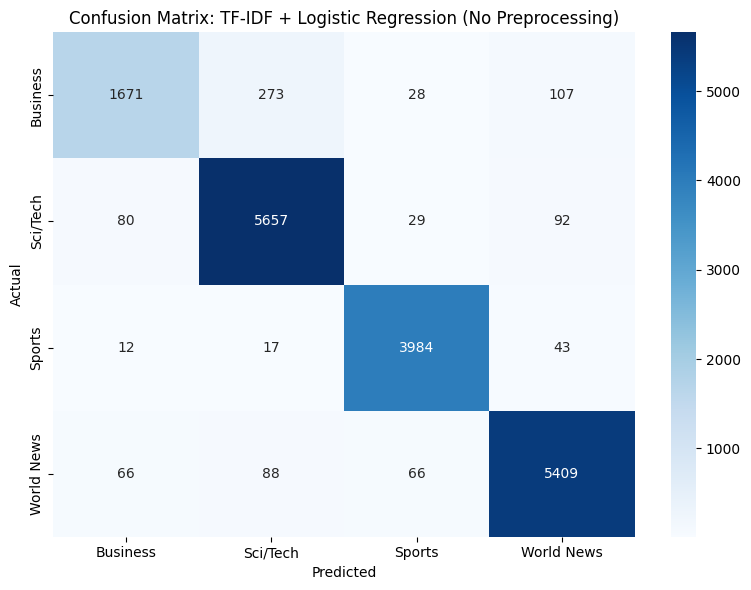


--- Test Set ---

Model: TF-IDF + Logistic Regression (Test) | Preprocessing: No Preprocessing
Accuracy: 0.9121
F1-Score (macro): 0.9114

Classification Report:
              precision    recall  f1-score   support

    Business       0.93      0.81      0.87      3000
    Sci/Tech       0.86      0.94      0.90      3000
      Sports       0.96      0.98      0.97      3000
  World News       0.90      0.92      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000



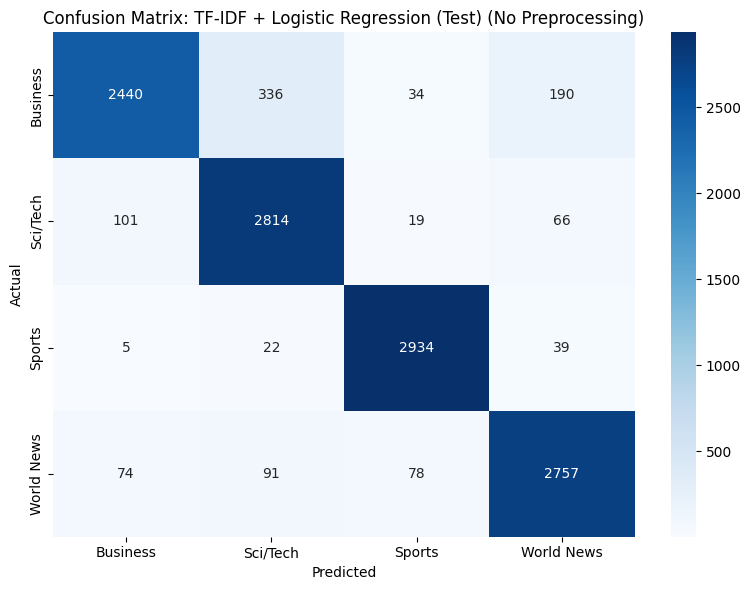

(0.9120833333333334, 0.9113901519717392)

In [37]:
# TF-IDF + Logistic Regression — No Preprocessing
tfidf_vectorizer_none = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf_none = tfidf_vectorizer_none.fit_transform(X_train_none)
X_val_tfidf_none = tfidf_vectorizer_none.transform(X_val_none)
X_test_tfidf_none = tfidf_vectorizer_none.transform(X_test_none)

print(f"TF-IDF matrix shape (train): {X_train_tfidf_none.shape}")

lr_model_none = LogisticRegression(max_iter=1000, C=best_C, solver='lbfgs', multi_class='multinomial', random_state=42)
lr_model_none.fit(X_train_tfidf_none, y_train)

# Evaluate on validation set
y_val_pred_lr_none = lr_model_none.predict(X_val_tfidf_none)
print("\n--- Validation Set ---")
evaluate_model('TF-IDF + Logistic Regression', 'No Preprocessing', y_val, y_val_pred_lr_none)

# Evaluate on test set
y_test_pred_lr_none = lr_model_none.predict(X_test_tfidf_none)
print("\n--- Test Set ---")
evaluate_model('TF-IDF + Logistic Regression (Test)', 'No Preprocessing', y_test, y_test_pred_lr_none)

### 6.2 TF-IDF + Logistic Regression — Extreme Preprocessing

TF-IDF matrix shape (train): (70484, 50000)

--- Validation Set ---

Model: TF-IDF + Logistic Regression | Preprocessing: Extreme Preprocessing
Accuracy: 0.9482
F1-Score (macro): 0.9351

Classification Report:
              precision    recall  f1-score   support

    Business       0.90      0.81      0.86      2079
    Sci/Tech       0.94      0.97      0.95      5858
      Sports       0.97      0.98      0.97      4056
  World News       0.96      0.96      0.96      5629

    accuracy                           0.95     17622
   macro avg       0.94      0.93      0.94     17622
weighted avg       0.95      0.95      0.95     17622



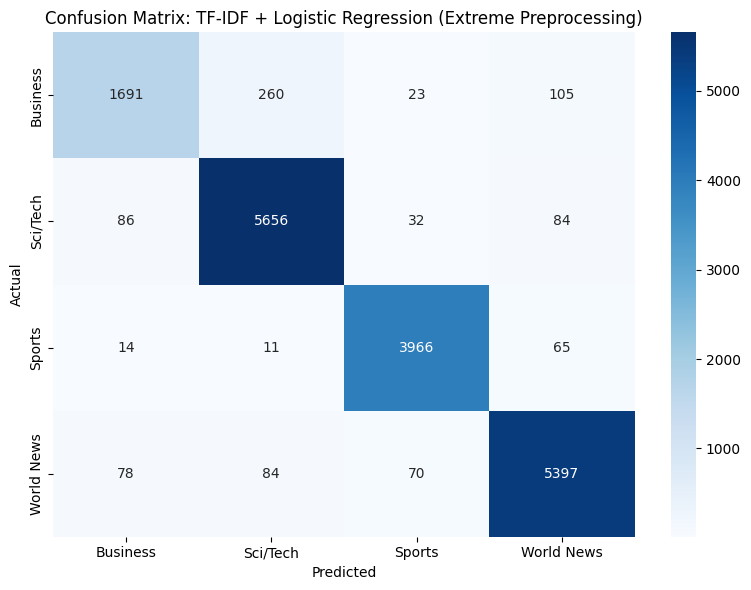


--- Test Set ---

Model: TF-IDF + Logistic Regression (Test) | Preprocessing: Extreme Preprocessing
Accuracy: 0.9137
F1-Score (macro): 0.9132

Classification Report:
              precision    recall  f1-score   support

    Business       0.93      0.83      0.87      3000
    Sci/Tech       0.87      0.93      0.90      3000
      Sports       0.96      0.98      0.97      3000
  World News       0.91      0.92      0.92      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000



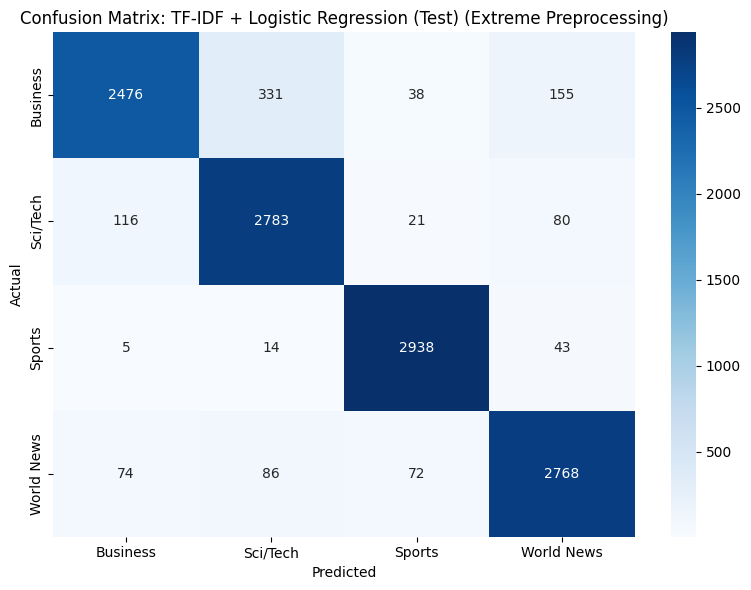

(0.91375, 0.9131949242272224)

In [38]:
# TF-IDF + Logistic Regression — Extreme Preprocessing
tfidf_vectorizer_extreme = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf_extreme = tfidf_vectorizer_extreme.fit_transform(X_train_extreme)
X_val_tfidf_extreme = tfidf_vectorizer_extreme.transform(X_val_extreme)
X_test_tfidf_extreme = tfidf_vectorizer_extreme.transform(X_test_extreme)

print(f"TF-IDF matrix shape (train): {X_train_tfidf_extreme.shape}")

lr_model_extreme = LogisticRegression(max_iter=1000, C=best_C, solver='lbfgs', multi_class='multinomial', random_state=42)
lr_model_extreme.fit(X_train_tfidf_extreme, y_train)

# Evaluate on validation set
y_val_pred_lr_extreme = lr_model_extreme.predict(X_val_tfidf_extreme)
print("\n--- Validation Set ---")
evaluate_model('TF-IDF + Logistic Regression', 'Extreme Preprocessing', y_val, y_val_pred_lr_extreme)

# Evaluate on test set
y_test_pred_lr_extreme = lr_model_extreme.predict(X_test_tfidf_extreme)
print("\n--- Test Set ---")
evaluate_model('TF-IDF + Logistic Regression (Test)', 'Extreme Preprocessing', y_test, y_test_pred_lr_extreme)

### 6.3 TF-IDF + Logistic Regression — Optimum Preprocessing

TF-IDF matrix shape (train): (70484, 50000)

--- Validation Set ---

Model: TF-IDF + Logistic Regression | Preprocessing: Optimum Preprocessing
Accuracy: 0.9499
F1-Score (macro): 0.9374

Classification Report:
              precision    recall  f1-score   support

    Business       0.91      0.82      0.86      2079
    Sci/Tech       0.94      0.97      0.95      5858
      Sports       0.97      0.98      0.98      4056
  World News       0.96      0.96      0.96      5629

    accuracy                           0.95     17622
   macro avg       0.95      0.93      0.94     17622
weighted avg       0.95      0.95      0.95     17622



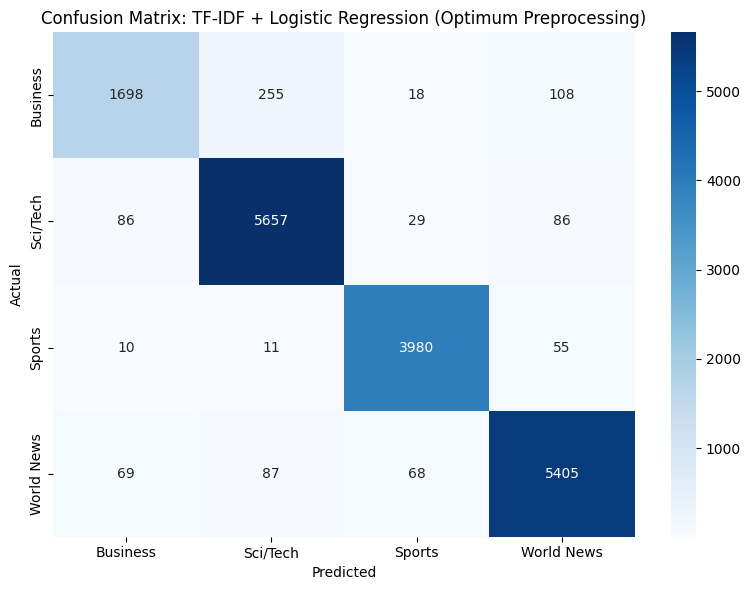


--- Test Set ---

Model: TF-IDF + Logistic Regression (Test) | Preprocessing: Optimum Preprocessing
Accuracy: 0.9136
F1-Score (macro): 0.9130

Classification Report:
              precision    recall  f1-score   support

    Business       0.93      0.82      0.87      3000
    Sci/Tech       0.86      0.93      0.90      3000
      Sports       0.96      0.98      0.97      3000
  World News       0.91      0.92      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.92      0.91      0.91     12000
weighted avg       0.92      0.91      0.91     12000



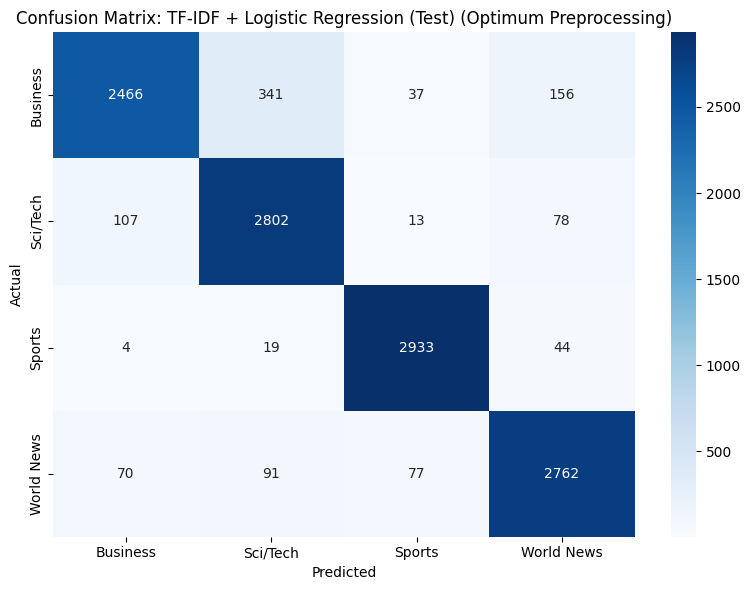

(0.9135833333333333, 0.9130375630353674)

In [39]:
# TF-IDF + Logistic Regression — Optimum Preprocessing
tfidf_vectorizer_optimum = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf_optimum = tfidf_vectorizer_optimum.fit_transform(X_train_optimum)
X_val_tfidf_optimum = tfidf_vectorizer_optimum.transform(X_val_optimum)
X_test_tfidf_optimum = tfidf_vectorizer_optimum.transform(X_test_optimum)

print(f"TF-IDF matrix shape (train): {X_train_tfidf_optimum.shape}")

lr_model_optimum = LogisticRegression(max_iter=1000, C=best_C, solver='lbfgs', multi_class='multinomial', random_state=42)
lr_model_optimum.fit(X_train_tfidf_optimum, y_train)

# Evaluate on validation set
y_val_pred_lr_optimum = lr_model_optimum.predict(X_val_tfidf_optimum)
print("\n--- Validation Set ---")
evaluate_model('TF-IDF + Logistic Regression', 'Optimum Preprocessing', y_val, y_val_pred_lr_optimum)

# Evaluate on test set
y_test_pred_lr_optimum = lr_model_optimum.predict(X_test_tfidf_optimum)
print("\n--- Test Set ---")
evaluate_model('TF-IDF + Logistic Regression (Test)', 'Optimum Preprocessing', y_test, y_test_pred_lr_optimum)

## 7. TF-IDF + Deep Neural Network
We train a Deep Neural Network (4+ layers, 128+ neurons in the first layer) using TF-IDF vectors.

In [40]:
# Re-import essentials (safe to re-run if runtime restarted)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, gc, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

### Sparse-to-Dense Batch Generator
To avoid MemoryError, we **never** convert the full TF-IDF matrix to dense. Instead, we use a generator that converts one small batch at a time during training.

In [41]:
# Sparse batch generator — converts only one batch to dense at a time
# Peak memory: ~batch_size × features × 4 bytes (e.g., 256 × 20000 × 4 = ~20 MB)
import scipy.sparse

def sparse_generator(X_sparse, y, batch_size, shuffle=True):
    n = X_sparse.shape[0]
    while True:
        indices = np.arange(n)
        if shuffle:
            np.random.shuffle(indices)
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            batch_idx = indices[start:end]
            X_batch = X_sparse[batch_idx].toarray().astype('float32')
            y_batch = y[batch_idx]
            yield X_batch, y_batch

print("Sparse batch generator defined — no full dense conversion needed.")

Sparse batch generator defined — no full dense conversion needed.


### 7.1 TF-IDF + Deep NN — No Preprocessing

In [42]:
# DNN No Preprocessing — Vectorize (stays sparse, ~200 MB)
tfidf_dnn_none = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_sp_none = tfidf_dnn_none.fit_transform(X_train_none).astype('float32')
X_val_sp_none = tfidf_dnn_none.transform(X_val_none).astype('float32')
X_test_sp_none = tfidf_dnn_none.transform(X_test_none).astype('float32')
del tfidf_dnn_none

n_features = X_train_sp_none.shape[1]
print(f"Sparse TF-IDF shape: {X_train_sp_none.shape}, nnz: {X_train_sp_none.nnz}")

Sparse TF-IDF shape: (70484, 20000), nnz: 3110121


In [43]:
# DNN No Preprocessing — Build model
y_train_cat = to_categorical(y_train, num_classes=4)
y_val_cat = to_categorical(y_val, num_classes=4)

dnn_model_none = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

dnn_model_none.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
dnn_model_none.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 256)            │     5,120,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,163,620 (19.70 MB)

 Trainable params: 5,163,620 (19.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8956 - loss: 0.3113 - val_accuracy: 0.9390 - val_loss: 0.1935
Epoch 2/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9652 - loss: 0.1127 - val_accuracy: 0.9425 - val_loss: 0.1969
Epoch 3/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9838 - loss: 0.0529 - val_accuracy: 0.9424 - val_loss: 0.2250
Epoch 4/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9919 - loss: 0.0264 - val_accuracy: 0.9423 - val_loss: 0.2865


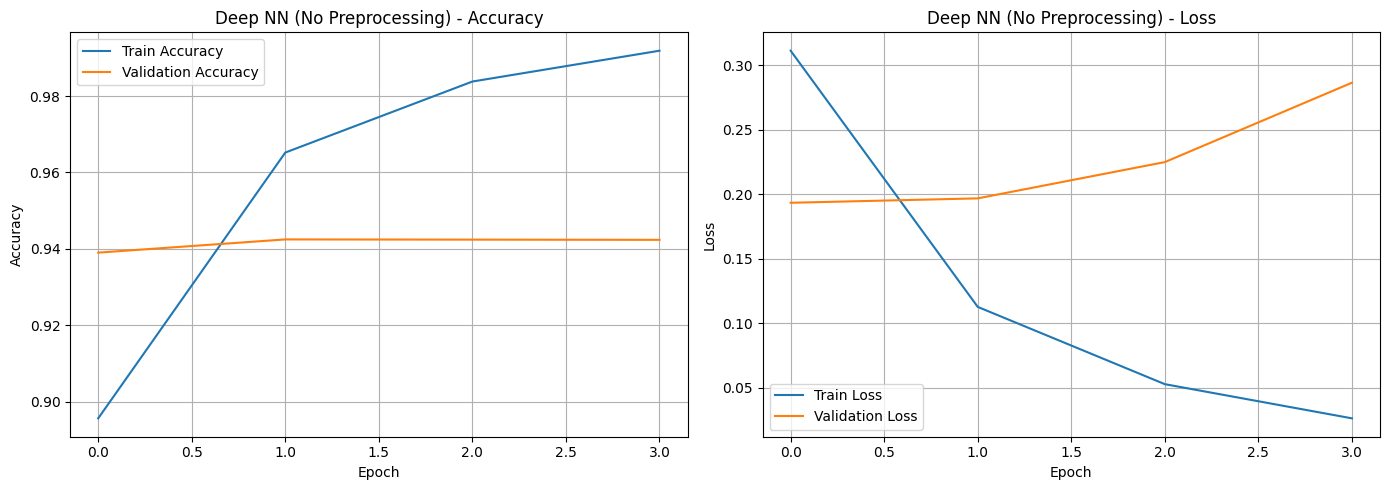

In [44]:
# DNN No Preprocessing — Train using sparse batch generator
BATCH_SIZE = best_batch if 'best_batch' in dir() else 256
train_steps = int(np.ceil(X_train_sp_none.shape[0] / BATCH_SIZE))
val_steps = int(np.ceil(X_val_sp_none.shape[0] / BATCH_SIZE))

train_gen = sparse_generator(X_train_sp_none, y_train_cat, BATCH_SIZE, shuffle=True)
val_gen = sparse_generator(X_val_sp_none, y_val_cat, BATCH_SIZE, shuffle=False)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_dnn_none = dnn_model_none.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=[early_stop],
    verbose=1
)

del X_train_sp_none, X_val_sp_none, y_train_cat, y_val_cat
import gc; gc.collect()

plot_training_history(history_dnn_none, 'Deep NN (No Preprocessing)')


Model: TF-IDF + Deep NN (Test) | Preprocessing: No Preprocessing
Accuracy: 0.9058
F1-Score (macro): 0.9049

Classification Report:
              precision    recall  f1-score   support

    Business       0.94      0.79      0.86      3000
    Sci/Tech       0.84      0.95      0.89      3000
      Sports       0.95      0.98      0.96      3000
  World News       0.91      0.91      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.90     12000
weighted avg       0.91      0.91      0.90     12000



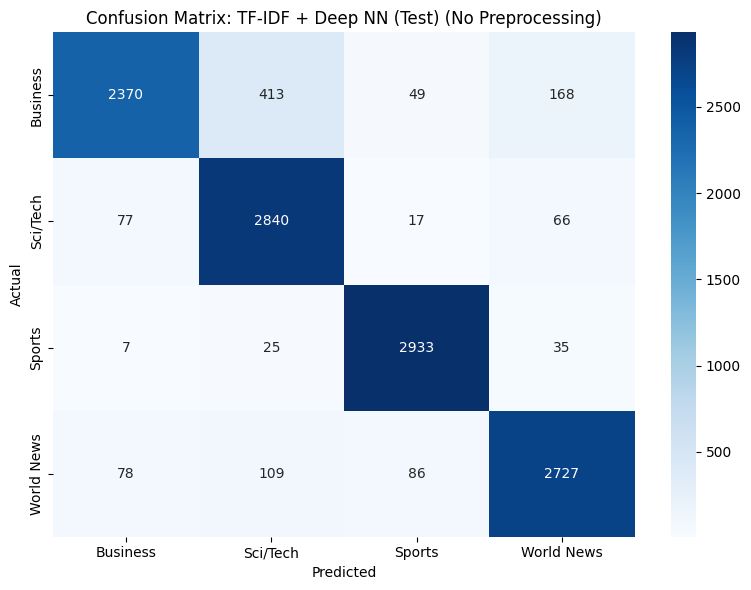

Memory freed for No Preprocessing DNN.


In [45]:
# DNN No Preprocessing — Evaluate on test set
# Convert test set in one shot (only ~36K × 20K × 4 = ~2.9 GB, much smaller than train)
# If still too large, we predict in batches
y_test_pred_dnn_none = []
BATCH_SIZE = 1000
for start in range(0, X_test_sp_none.shape[0], BATCH_SIZE):
    end = min(start + BATCH_SIZE, X_test_sp_none.shape[0])
    batch_dense = X_test_sp_none[start:end].toarray().astype('float32')
    preds = np.argmax(dnn_model_none.predict(batch_dense, verbose=0), axis=1)
    y_test_pred_dnn_none.extend(preds)
    del batch_dense

y_test_pred_dnn_none = np.array(y_test_pred_dnn_none)
evaluate_model('TF-IDF + Deep NN (Test)', 'No Preprocessing', y_test, y_test_pred_dnn_none)

# Cleanup
del X_test_sp_none, dnn_model_none
import gc; gc.collect()
print("Memory freed for No Preprocessing DNN.")

### 7.2 TF-IDF + Deep NN — Extreme Preprocessing

In [46]:
# DNN Extreme Preprocessing — Vectorize (stays sparse, ~200 MB)
tfidf_dnn_extreme = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_sp_extreme = tfidf_dnn_extreme.fit_transform(X_train_extreme).astype('float32')
X_val_sp_extreme = tfidf_dnn_extreme.transform(X_val_extreme).astype('float32')
X_test_sp_extreme = tfidf_dnn_extreme.transform(X_test_extreme).astype('float32')
del tfidf_dnn_extreme

n_features = X_train_sp_extreme.shape[1]
print(f"Sparse TF-IDF shape: {X_train_sp_extreme.shape}, nnz: {X_train_sp_extreme.nnz}")

Sparse TF-IDF shape: (70484, 20000), nnz: 1988490


In [47]:
# DNN Extreme Preprocessing — Build model
y_train_cat = to_categorical(y_train, num_classes=4)
y_val_cat = to_categorical(y_val, num_classes=4)

dnn_model_extreme = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

dnn_model_extreme.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
dnn_model_extreme.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 256)            │     5,120,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,163,620 (19.70 MB)

 Trainable params: 5,163,620 (19.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8949 - loss: 0.3084 - val_accuracy: 0.9396 - val_loss: 0.1937
Epoch 2/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9618 - loss: 0.1196 - val_accuracy: 0.9442 - val_loss: 0.1889
Epoch 3/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9809 - loss: 0.0596 - val_accuracy: 0.9465 - val_loss: 0.2324
Epoch 4/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9894 - loss: 0.0314 - val_accuracy: 0.9450 - val_loss: 0.2798
Epoch 5/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9939 - loss: 0.0194 - val_accuracy: 0.9464 - val_loss: 0.3173


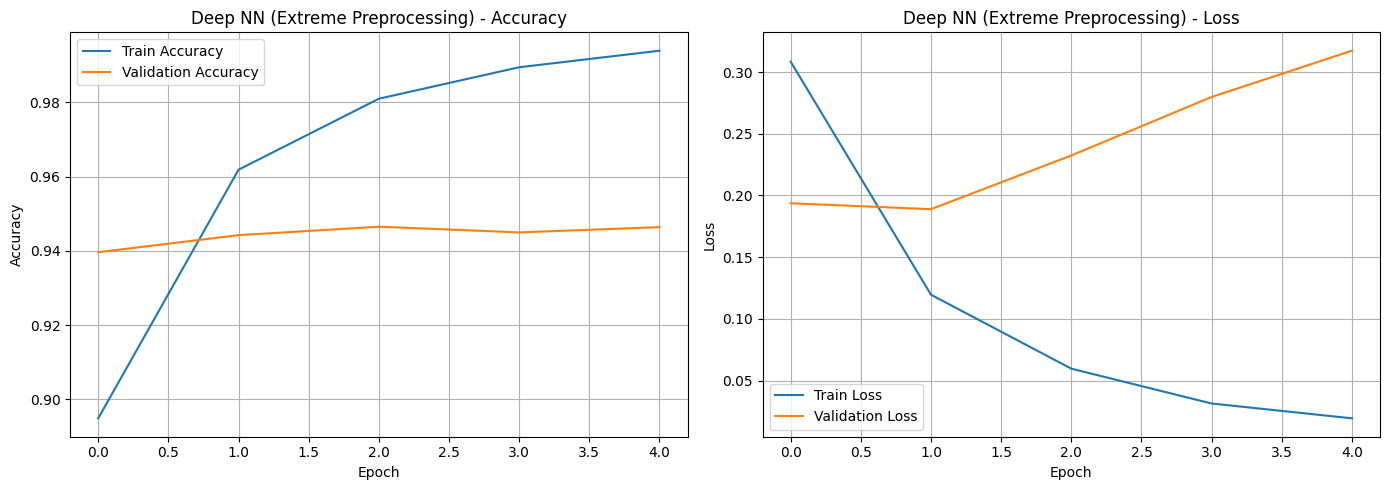

In [48]:
# DNN Extreme Preprocessing — Train using sparse batch generator
BATCH_SIZE = best_batch if 'best_batch' in dir() else 256
train_steps = int(np.ceil(X_train_sp_extreme.shape[0] / BATCH_SIZE))
val_steps = int(np.ceil(X_val_sp_extreme.shape[0] / BATCH_SIZE))

train_gen = sparse_generator(X_train_sp_extreme, y_train_cat, BATCH_SIZE, shuffle=True)
val_gen = sparse_generator(X_val_sp_extreme, y_val_cat, BATCH_SIZE, shuffle=False)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_dnn_extreme = dnn_model_extreme.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=[early_stop],
    verbose=1
)

del X_train_sp_extreme, X_val_sp_extreme, y_train_cat, y_val_cat
import gc; gc.collect()

plot_training_history(history_dnn_extreme, 'Deep NN (Extreme Preprocessing)')


Model: TF-IDF + Deep NN (Test) | Preprocessing: Extreme Preprocessing
Accuracy: 0.9117
F1-Score (macro): 0.9114

Classification Report:
              precision    recall  f1-score   support

    Business       0.91      0.84      0.87      3000
    Sci/Tech       0.86      0.94      0.89      3000
      Sports       0.96      0.98      0.97      3000
  World News       0.93      0.90      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000



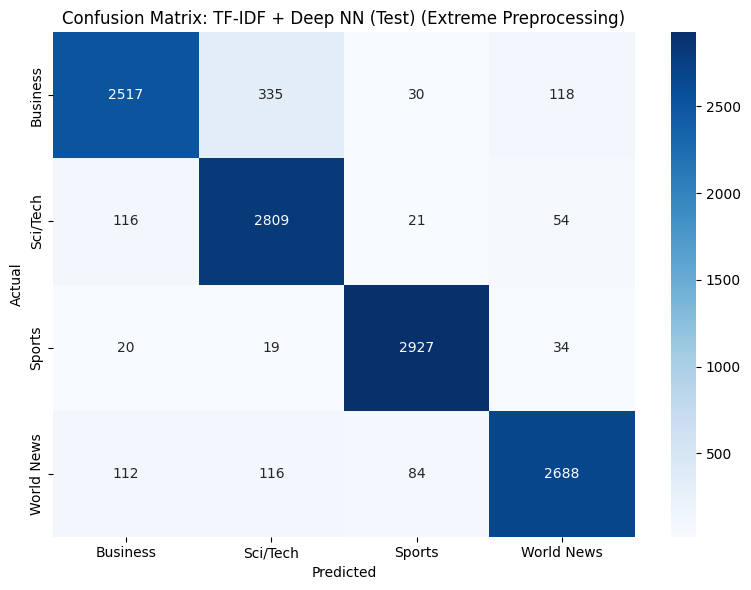

Memory freed for Extreme Preprocessing DNN.


In [49]:
# DNN Extreme Preprocessing — Evaluate on test set
# Convert test set in one shot (only ~36K × 20K × 4 = ~2.9 GB, much smaller than train)
# If still too large, we predict in batches
y_test_pred_dnn_extreme = []
BATCH_SIZE = 1000
for start in range(0, X_test_sp_extreme.shape[0], BATCH_SIZE):
    end = min(start + BATCH_SIZE, X_test_sp_extreme.shape[0])
    batch_dense = X_test_sp_extreme[start:end].toarray().astype('float32')
    preds = np.argmax(dnn_model_extreme.predict(batch_dense, verbose=0), axis=1)
    y_test_pred_dnn_extreme.extend(preds)
    del batch_dense

y_test_pred_dnn_extreme = np.array(y_test_pred_dnn_extreme)
evaluate_model('TF-IDF + Deep NN (Test)', 'Extreme Preprocessing', y_test, y_test_pred_dnn_extreme)

# Cleanup
del X_test_sp_extreme, dnn_model_extreme
import gc; gc.collect()
print("Memory freed for Extreme Preprocessing DNN.")

### 7.3 TF-IDF + Deep NN — Optimum Preprocessing

In [50]:
# DNN Optimum Preprocessing — Vectorize (stays sparse, ~200 MB)
tfidf_dnn_optimum = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_sp_optimum = tfidf_dnn_optimum.fit_transform(X_train_optimum).astype('float32')
X_val_sp_optimum = tfidf_dnn_optimum.transform(X_val_optimum).astype('float32')
X_test_sp_optimum = tfidf_dnn_optimum.transform(X_test_optimum).astype('float32')
del tfidf_dnn_optimum

n_features = X_train_sp_optimum.shape[1]
print(f"Sparse TF-IDF shape: {X_train_sp_optimum.shape}, nnz: {X_train_sp_optimum.nnz}")

Sparse TF-IDF shape: (70484, 20000), nnz: 1976663


In [51]:
# DNN Optimum Preprocessing — Build model
y_train_cat = to_categorical(y_train, num_classes=4)
y_val_cat = to_categorical(y_val, num_classes=4)

dnn_model_optimum = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

dnn_model_optimum.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
dnn_model_optimum.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_53 (Dense)                │ (None, 256)            │     5,120,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,163,620 (19.70 MB)

 Trainable params: 5,163,620 (19.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.8961 - loss: 0.3074 - val_accuracy: 0.9369 - val_loss: 0.1935
Epoch 2/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9623 - loss: 0.1155 - val_accuracy: 0.9439 - val_loss: 0.1848
Epoch 3/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9828 - loss: 0.0551 - val_accuracy: 0.9459 - val_loss: 0.2238
Epoch 4/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9906 - loss: 0.0283 - val_accuracy: 0.9446 - val_loss: 0.2739
Epoch 5/20
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9942 - loss: 0.0187 - val_accuracy: 0.9440 - val_loss: 0.3080


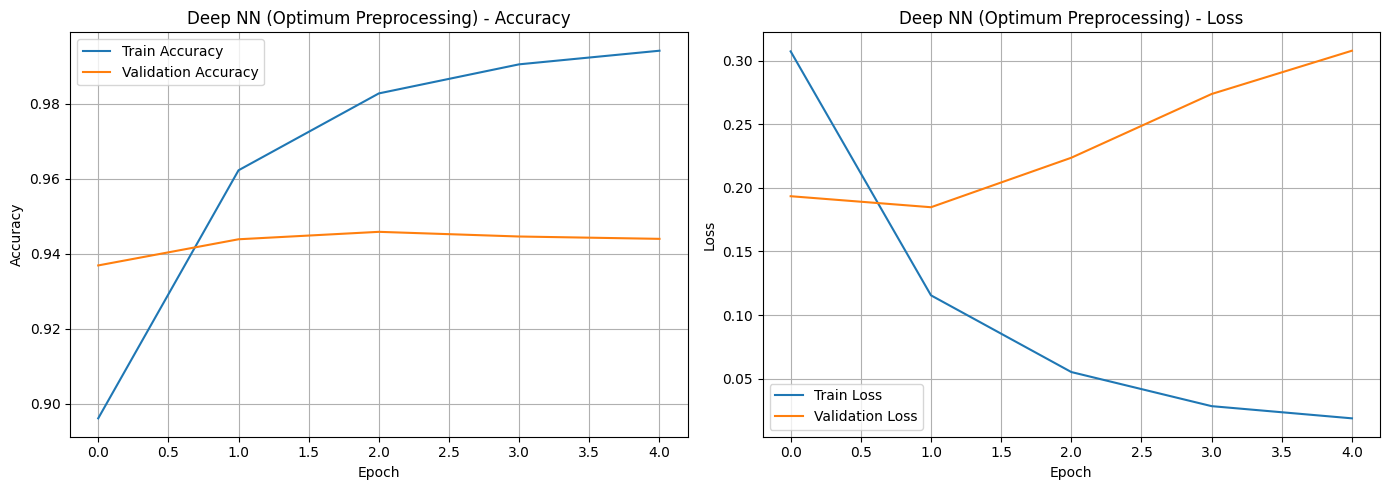

In [52]:
# DNN Optimum Preprocessing — Train using sparse batch generator
BATCH_SIZE = best_batch if 'best_batch' in dir() else 256
train_steps = int(np.ceil(X_train_sp_optimum.shape[0] / BATCH_SIZE))
val_steps = int(np.ceil(X_val_sp_optimum.shape[0] / BATCH_SIZE))

train_gen = sparse_generator(X_train_sp_optimum, y_train_cat, BATCH_SIZE, shuffle=True)
val_gen = sparse_generator(X_val_sp_optimum, y_val_cat, BATCH_SIZE, shuffle=False)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_dnn_optimum = dnn_model_optimum.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=20,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=[early_stop],
    verbose=1
)

del X_train_sp_optimum, X_val_sp_optimum, y_train_cat, y_val_cat
import gc; gc.collect()

plot_training_history(history_dnn_optimum, 'Deep NN (Optimum Preprocessing)')


Model: TF-IDF + Deep NN (Test) | Preprocessing: Optimum Preprocessing
Accuracy: 0.9123
F1-Score (macro): 0.9116

Classification Report:
              precision    recall  f1-score   support

    Business       0.93      0.82      0.87      3000
    Sci/Tech       0.85      0.94      0.89      3000
      Sports       0.95      0.98      0.97      3000
  World News       0.92      0.91      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000



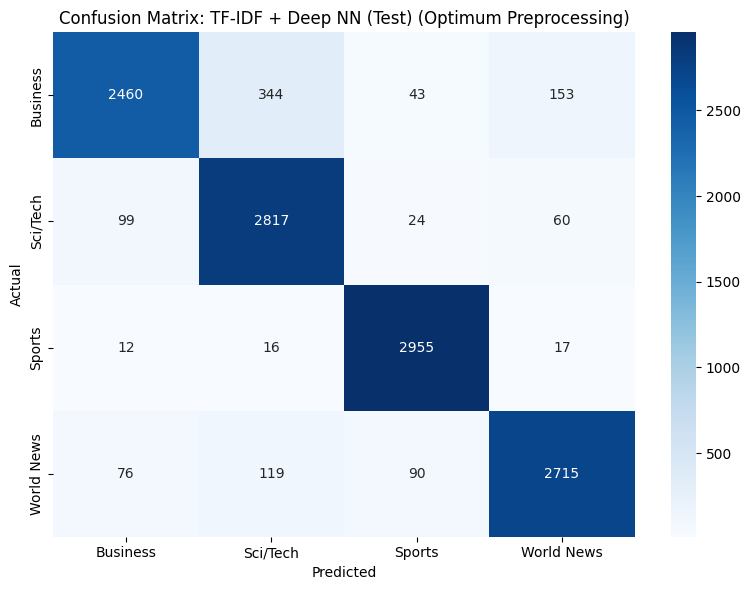

Memory freed for Optimum Preprocessing DNN.


In [53]:
# DNN Optimum Preprocessing — Evaluate on test set
# Convert test set in one shot (only ~36K × 20K × 4 = ~2.9 GB, much smaller than train)
# If still too large, we predict in batches
y_test_pred_dnn_optimum = []
BATCH_SIZE = 1000
for start in range(0, X_test_sp_optimum.shape[0], BATCH_SIZE):
    end = min(start + BATCH_SIZE, X_test_sp_optimum.shape[0])
    batch_dense = X_test_sp_optimum[start:end].toarray().astype('float32')
    preds = np.argmax(dnn_model_optimum.predict(batch_dense, verbose=0), axis=1)
    y_test_pred_dnn_optimum.extend(preds)
    del batch_dense

y_test_pred_dnn_optimum = np.array(y_test_pred_dnn_optimum)
evaluate_model('TF-IDF + Deep NN (Test)', 'Optimum Preprocessing', y_test, y_test_pred_dnn_optimum)

# Cleanup
del X_test_sp_optimum, dnn_model_optimum
import gc; gc.collect()
print("Memory freed for Optimum Preprocessing DNN.")

## 8. Skip-gram Word Embeddings
We train a Word2Vec Skip-gram model on the training corpus for each preprocessing variant. The embedding matrix is then used as initial weights in the Embedding layer of the RNN models.

In [54]:
# Re-import essentials (safe to re-run if runtime restarted)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, gc, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [55]:
# Tokenizer data already built in Section 5.5.4
print('Tokenizer data shapes:')
for k, v in tokenizer_data.items():
    print(f"  {k}: X_train_seq={v['X_train_seq'].shape}, X_val_seq={v['X_val_seq'].shape}, X_test_seq={v['X_test_seq'].shape}")

Tokenizer data shapes:
  none: X_train_seq=(70484, 100), X_val_seq=(17622, 100), X_test_seq=(12000, 100)
  extreme: X_train_seq=(70484, 100), X_val_seq=(17622, 100), X_test_seq=(12000, 100)
  optimum: X_train_seq=(70484, 100), X_val_seq=(17622, 100), X_test_seq=(12000, 100)


In [56]:
# Skip-gram embeddings already built in Section 5.5.4
print('Embedding matrix shapes:')
for k, v in embedding_matrices.items():
    print(f"  {k}: {v.shape}")

Embedding matrix shapes:
  none: (20000, 100)
  extreme: (20000, 100)
  optimum: (20000, 100)


## 9. Skip-gram + RNN Models
We train all 6 RNN-family models (SimpleRNN, GRU, LSTM, and their Bidirectional variants) for each preprocessing variant. That gives us 18 training runs in this section.

In [57]:
# Re-import essentials (safe to re-run if runtime restarted)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, gc, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

### 9.1 SimpleRNN

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.3275 - loss: 1.3265 - val_accuracy: 0.3352 - val_loss: 1.3193
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.3303 - loss: 1.3201 - val_accuracy: 0.3228 - val_loss: 1.3241
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.3308 - loss: 1.3189 - val_accuracy: 0.3340 - val_loss: 1.3199
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.3317 - loss: 1.3179 - val_accuracy: 0.3364 - val_loss: 1.3197


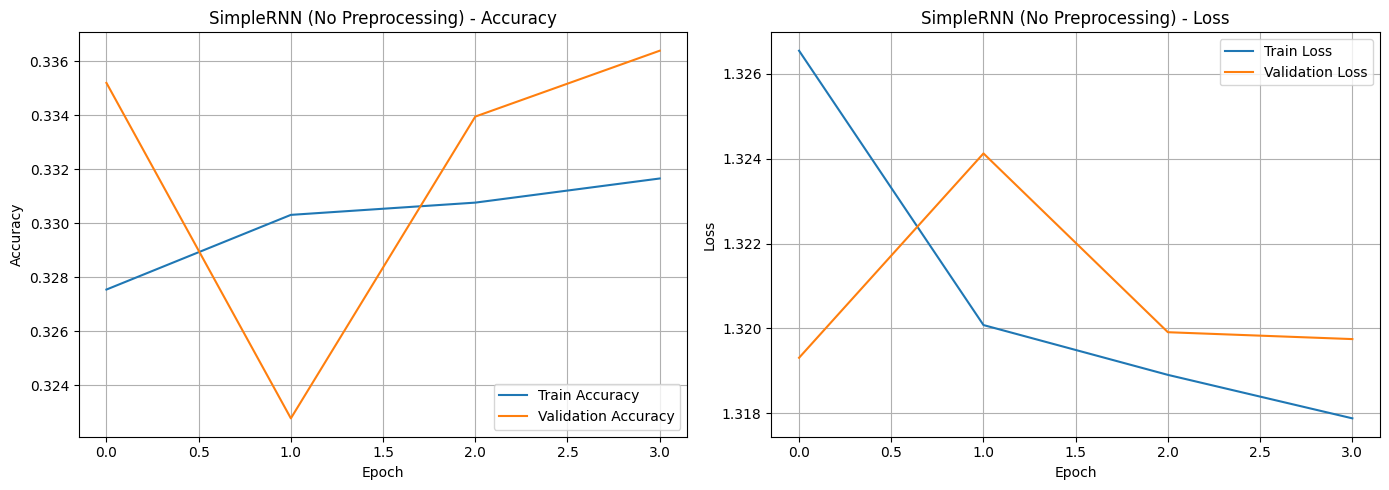

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Model: SimpleRNN (Test) | Preprocessing: No Preprocessing
Accuracy: 0.2475
F1-Score (macro): 0.1650

Classification Report:
              precision    recall  f1-score   support

    Business       0.00      0.00      0.00      3000
    Sci/Tech       0.25      0.50      0.33      3000
      Sports       0.00      0.00      0.00      3000
  World News       0.25      0.49      0.33      3000

    accuracy                           0.25     12000
   macro avg       0.12      0.25      0.17     12000
weighted avg       0.12      0.25      0.17     12000



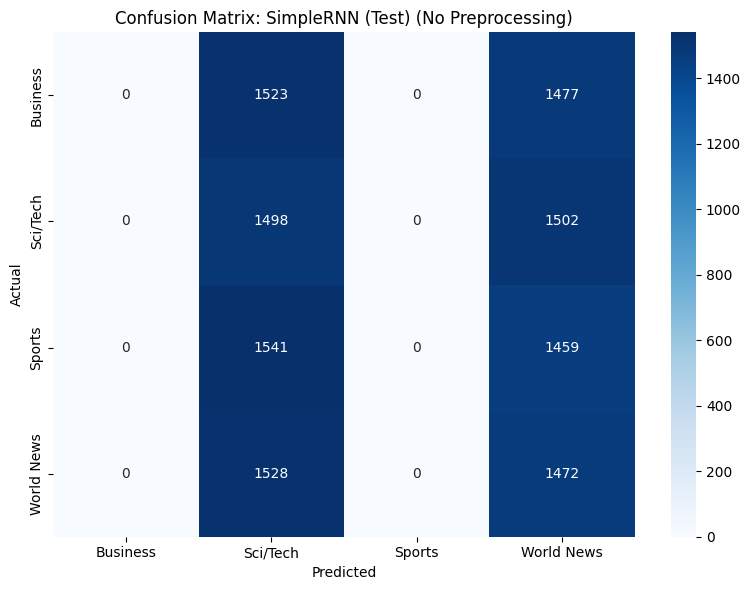

(0.2475, 0.16500205576113167)

In [58]:
# SimpleRNN — No Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['none']
vocab_size = embedding_matrices['none'].shape[0]

model_SimpleRNN_none = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['none']], trainable=True),
    SimpleRNN(best_rnn_units),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_SimpleRNN_none.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_SimpleRNN_none.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_SimpleRNN_none = model_SimpleRNN_none.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_SimpleRNN_none, 'SimpleRNN (No Preprocessing)')

# Evaluate on test set
y_test_pred_SimpleRNN_none = np.argmax(model_SimpleRNN_none.predict(td['X_test_seq']), axis=1)
evaluate_model('SimpleRNN (Test)', 'No Preprocessing', y_test, y_test_pred_SimpleRNN_none)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.5943 - loss: 0.9626 - val_accuracy: 0.3324 - val_loss: 1.3273
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.3233 - loss: 1.3351 - val_accuracy: 0.3194 - val_loss: 1.3235
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5579 - loss: 1.0291 - val_accuracy: 0.5806 - val_loss: 1.0002
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6150 - loss: 0.9171 - val_accuracy: 0.7427 - val_loss: 0.6879
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8324 - loss: 0.4740 - val_accuracy: 0.7836 - val_loss: 0.5495
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8863 - loss: 0.3596 - val_accuracy: 0.8385 - val_loss: 0.4704
Epoch 7/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8183 - loss: 0.5432 - val_accuracy: 0.8325 - val_loss: 0.5541
Epoch 8/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6758 -

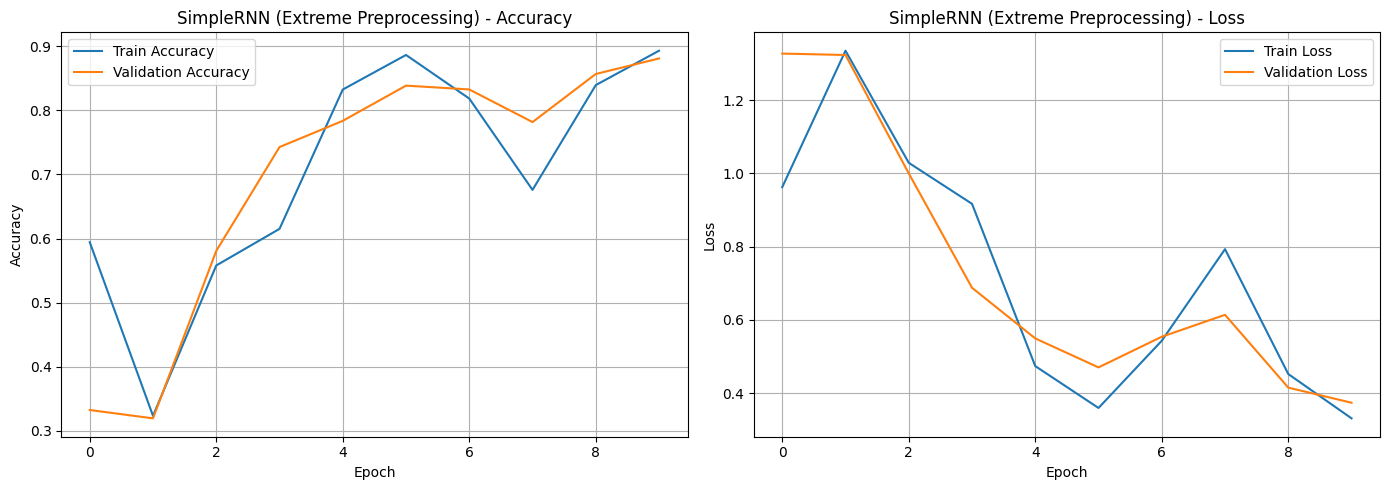

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model: SimpleRNN (Test) | Preprocessing: Extreme Preprocessing
Accuracy: 0.8276
F1-Score (macro): 0.8271

Classification Report:
              precision    recall  f1-score   support

    Business       0.74      0.71      0.72      3000
    Sci/Tech       0.82      0.84      0.83      3000
      Sports       0.94      0.93      0.94      3000
  World News       0.81      0.84      0.82      3000

    accuracy                           0.83     12000
   macro avg       0.83      0.83      0.83     12000
weighted avg       0.83      0.83      0.83     12000



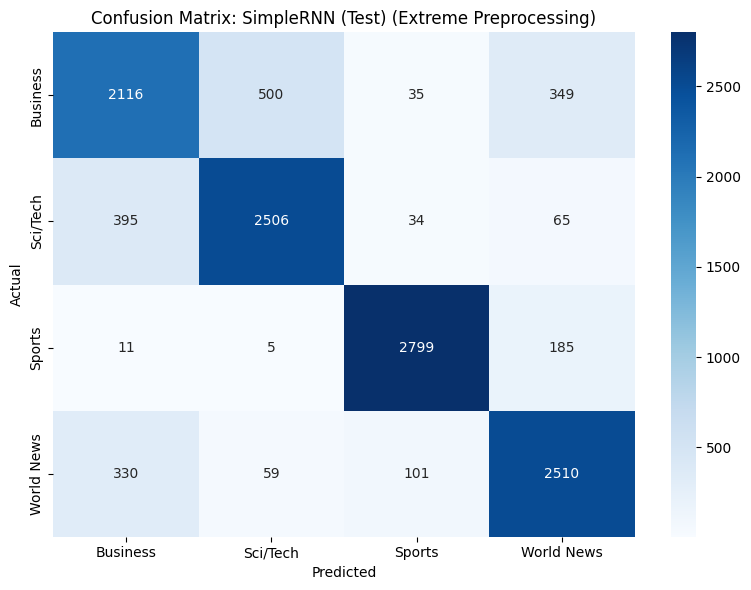

(0.8275833333333333, 0.8271139210033704)

In [59]:
# SimpleRNN — Extreme Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['extreme']
vocab_size = embedding_matrices['extreme'].shape[0]

model_SimpleRNN_extreme = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['extreme']], trainable=True),
    SimpleRNN(best_rnn_units),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_SimpleRNN_extreme.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_SimpleRNN_extreme.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_SimpleRNN_extreme = model_SimpleRNN_extreme.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_SimpleRNN_extreme, 'SimpleRNN (Extreme Preprocessing)')

# Evaluate on test set
y_test_pred_SimpleRNN_extreme = np.argmax(model_SimpleRNN_extreme.predict(td['X_test_seq']), axis=1)
evaluate_model('SimpleRNN (Test)', 'Extreme Preprocessing', y_test, y_test_pred_SimpleRNN_extreme)

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.6684 - loss: 0.8874 - val_accuracy: 0.7657 - val_loss: 0.6798
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8013 - loss: 0.6078 - val_accuracy: 0.8059 - val_loss: 0.5866
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5333 - loss: 1.0251 - val_accuracy: 0.3988 - val_loss: 1.2404
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.3953 - loss: 1.2501 - val_accuracy: 0.3387 - val_loss: 1.2836
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.3600 - loss: 1.2836 - val_accuracy: 0.3691 - val_loss: 1.2745


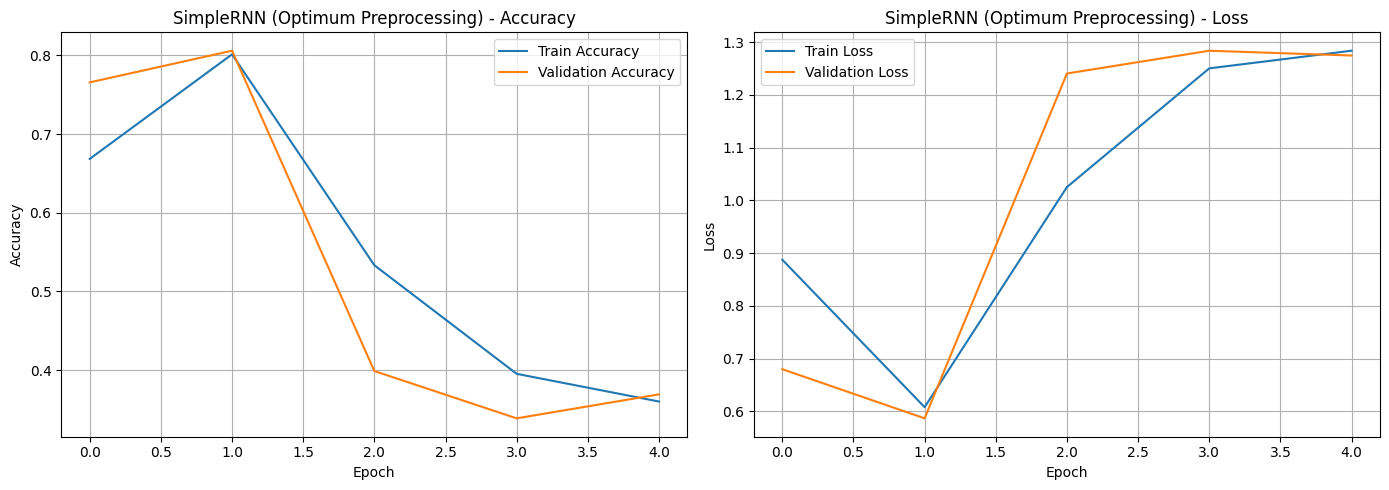

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model: SimpleRNN (Test) | Preprocessing: Optimum Preprocessing
Accuracy: 0.6803
F1-Score (macro): 0.6083

Classification Report:
              precision    recall  f1-score   support

    Business       0.64      0.03      0.06      3000
    Sci/Tech       0.49      0.92      0.64      3000
      Sports       0.83      0.95      0.88      3000
  World News       0.88      0.82      0.85      3000

    accuracy                           0.68     12000
   macro avg       0.71      0.68      0.61     12000
weighted avg       0.71      0.68      0.61     12000



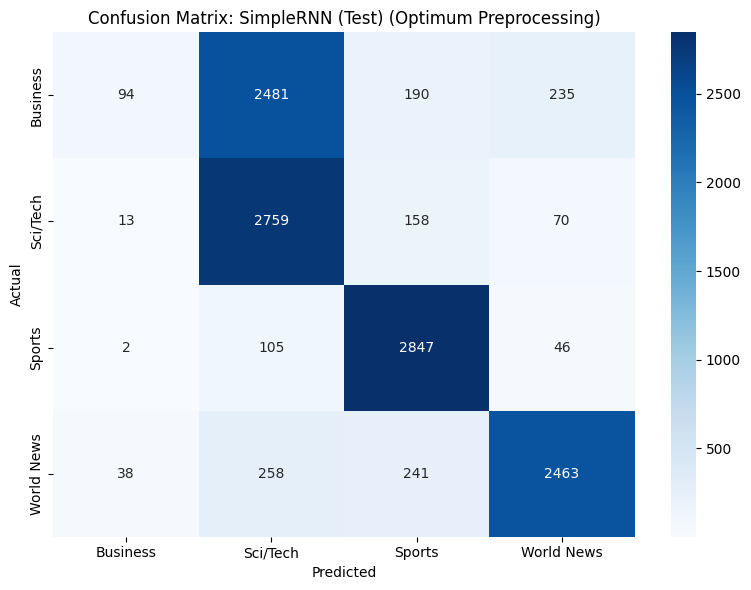

(0.68025, 0.6082799545551869)

In [60]:
# SimpleRNN — Optimum Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['optimum']
vocab_size = embedding_matrices['optimum'].shape[0]

model_SimpleRNN_optimum = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['optimum']], trainable=True),
    SimpleRNN(best_rnn_units),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_SimpleRNN_optimum.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_SimpleRNN_optimum.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_SimpleRNN_optimum = model_SimpleRNN_optimum.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_SimpleRNN_optimum, 'SimpleRNN (Optimum Preprocessing)')

# Evaluate on test set
y_test_pred_SimpleRNN_optimum = np.argmax(model_SimpleRNN_optimum.predict(td['X_test_seq']), axis=1)
evaluate_model('SimpleRNN (Test)', 'Optimum Preprocessing', y_test, y_test_pred_SimpleRNN_optimum)

### 9.2 GRU

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3546 - loss: 1.2794 - val_accuracy: 0.7327 - val_loss: 0.6479
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9105 - loss: 0.2762 - val_accuracy: 0.9377 - val_loss: 0.1997
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9536 - loss: 0.1463 - val_accuracy: 0.9460 - val_loss: 0.1718
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9725 - loss: 0.0893 - val_accuracy: 0.9455 - val_loss: 0.1835
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9837 - loss: 0.0549 - val_accuracy: 0.9476 - val_loss: 0.2021
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9907 - loss: 0.0321 - val_accuracy: 0.9445 - val_loss: 0.2381


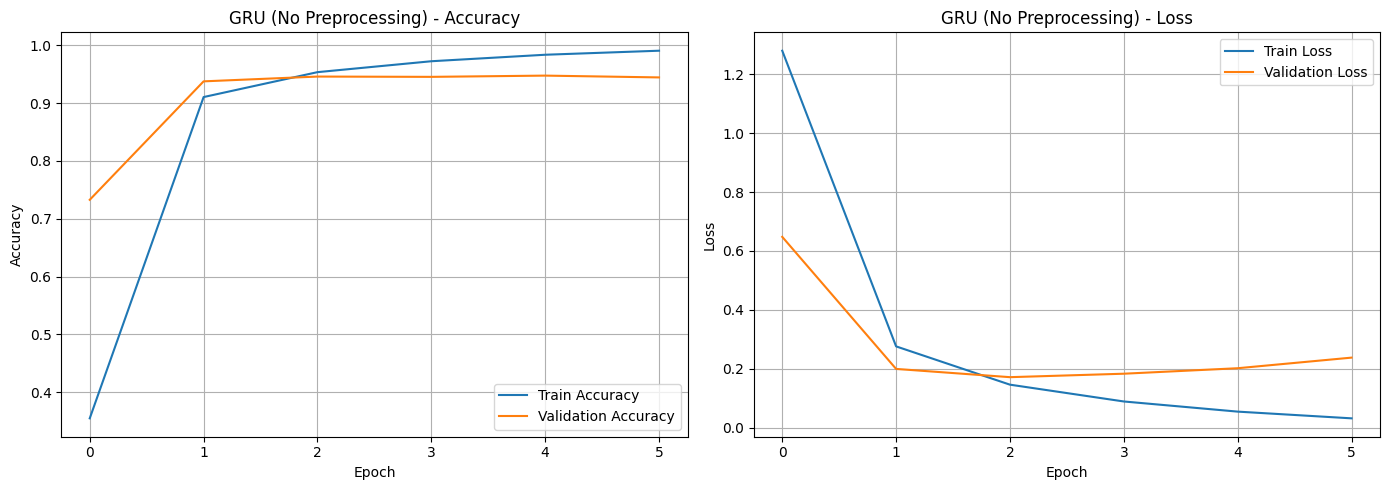

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model: GRU (Test) | Preprocessing: No Preprocessing
Accuracy: 0.9187
F1-Score (macro): 0.9183

Classification Report:
              precision    recall  f1-score   support

    Business       0.92      0.85      0.88      3000
    Sci/Tech       0.88      0.94      0.91      3000
      Sports       0.96      0.98      0.97      3000
  World News       0.92      0.91      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



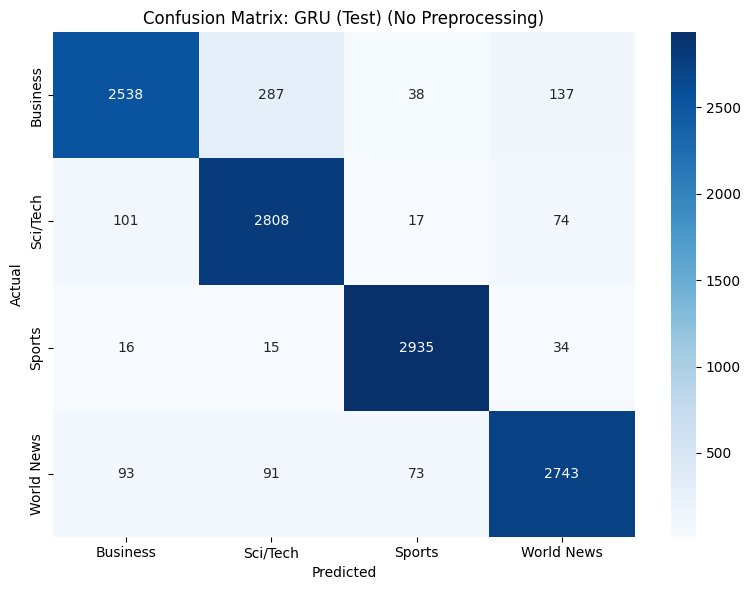

(0.9186666666666666, 0.9182708465461003)

In [61]:
# GRU — No Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['none']
vocab_size = embedding_matrices['none'].shape[0]

model_GRU_none = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['none']], trainable=True),
    GRU(best_rnn_units),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_GRU_none.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_GRU_none.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_GRU_none = model_GRU_none.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_GRU_none, 'GRU (No Preprocessing)')

# Evaluate on test set
y_test_pred_GRU_none = np.argmax(model_GRU_none.predict(td['X_test_seq']), axis=1)
evaluate_model('GRU (Test)', 'No Preprocessing', y_test, y_test_pred_GRU_none)

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3252 - loss: 1.3258 - val_accuracy: 0.3324 - val_loss: 1.3215
Epoch 2/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3281 - loss: 1.3234 - val_accuracy: 0.3324 - val_loss: 1.3232
Epoch 3/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3296 - loss: 1.3225 - val_accuracy: 0.3324 - val_loss: 1.3216
Epoch 4/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3297 - loss: 1.3224 - val_accuracy: 0.3324 - val_loss: 1.3211
Epoch 5/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3296 - loss: 1.3219 - val_accuracy: 0.3324 - val_loss: 1.3214
Epoch 6/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3307 - loss: 1.3219 - val_accuracy: 0.3324 - val_loss: 1.3210
Epoch 7/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3295 - loss: 1.3219 - val_accuracy: 0.3324 - val_loss: 1.3212
Epoch 8/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3304 - loss: 1.3216 - val_ac

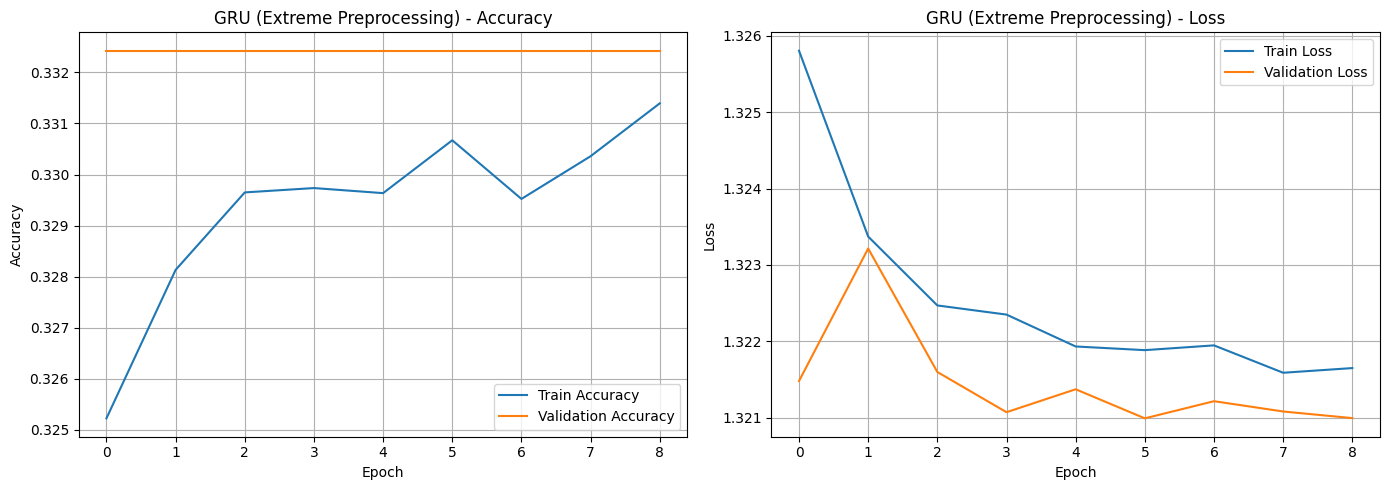

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model: GRU (Test) | Preprocessing: Extreme Preprocessing
Accuracy: 0.2500
F1-Score (macro): 0.1000

Classification Report:
              precision    recall  f1-score   support

    Business       0.00      0.00      0.00      3000
    Sci/Tech       0.25      1.00      0.40      3000
      Sports       0.00      0.00      0.00      3000
  World News       0.00      0.00      0.00      3000

    accuracy                           0.25     12000
   macro avg       0.06      0.25      0.10     12000
weighted avg       0.06      0.25      0.10     12000



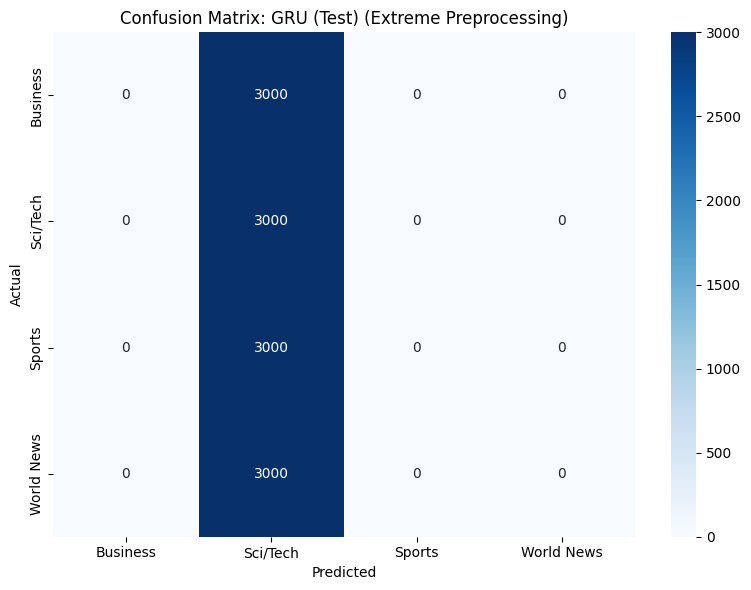

(0.25, 0.1)

In [62]:
# GRU — Extreme Preprocessing
# Fixed: using 64 units + 0.5 dropout (32 units caused model to get stuck at 25%)
td = tokenizer_data['extreme']
vocab_size = embedding_matrices['extreme'].shape[0]

model_GRU_extreme = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['extreme']], trainable=True),
    GRU(64),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model_GRU_extreme.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_GRU_extreme.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_GRU_extreme = model_GRU_extreme.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=128,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_GRU_extreme, 'GRU (Extreme Preprocessing)')

# Evaluate on test set
y_test_pred_GRU_extreme = np.argmax(model_GRU_extreme.predict(td['X_test_seq']), axis=1)
evaluate_model('GRU (Test)', 'Extreme Preprocessing', y_test, y_test_pred_GRU_extreme)

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3277 - loss: 1.3261 - val_accuracy: 0.3324 - val_loss: 1.3212
Epoch 2/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.3289 - loss: 1.3229 - val_accuracy: 0.3324 - val_loss: 1.3210
Epoch 3/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3282 - loss: 1.3227 - val_accuracy: 0.3324 - val_loss: 1.3212
Epoch 4/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3282 - loss: 1.3222 - val_accuracy: 0.3324 - val_loss: 1.3210
Epoch 5/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3303 - loss: 1.3220 - val_accuracy: 0.3195 - val_loss: 1.3218
Epoch 6/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3290 - loss: 1.3219 - val_accuracy: 0.3324 - val_loss: 1.3209
Epoch 7/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3296 - loss: 1.3220 - val_accuracy: 0.3324 - val_loss: 1.3211
Epoch 8/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3307 - loss: 1.3216 - val_accu

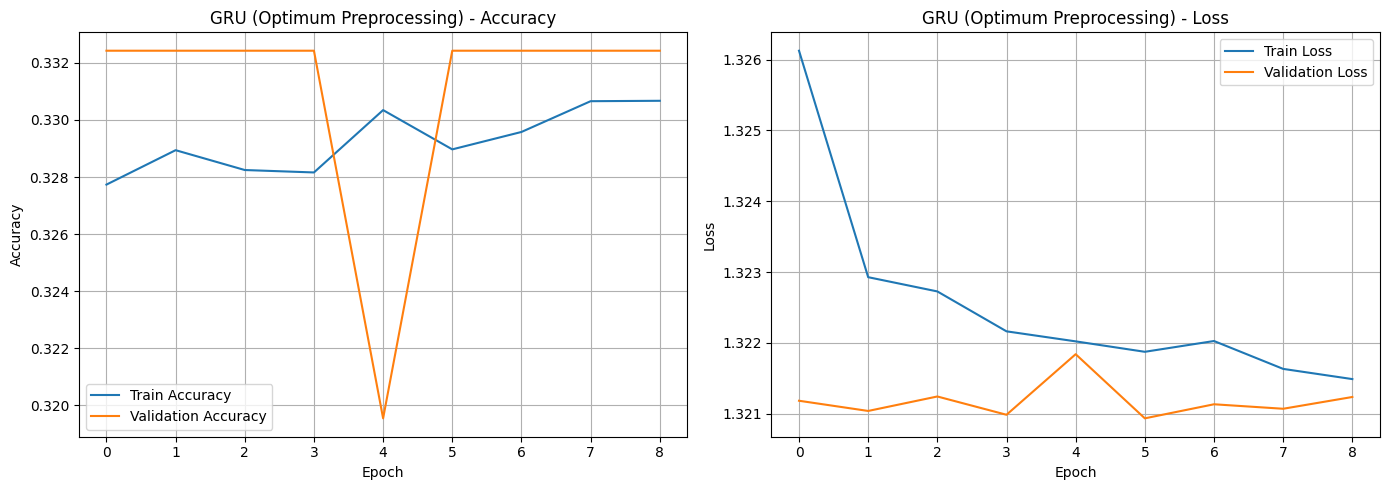

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model: GRU (Test) | Preprocessing: Optimum Preprocessing
Accuracy: 0.2500
F1-Score (macro): 0.1000

Classification Report:
              precision    recall  f1-score   support

    Business       0.00      0.00      0.00      3000
    Sci/Tech       0.25      1.00      0.40      3000
      Sports       0.00      0.00      0.00      3000
  World News       0.00      0.00      0.00      3000

    accuracy                           0.25     12000
   macro avg       0.06      0.25      0.10     12000
weighted avg       0.06      0.25      0.10     12000



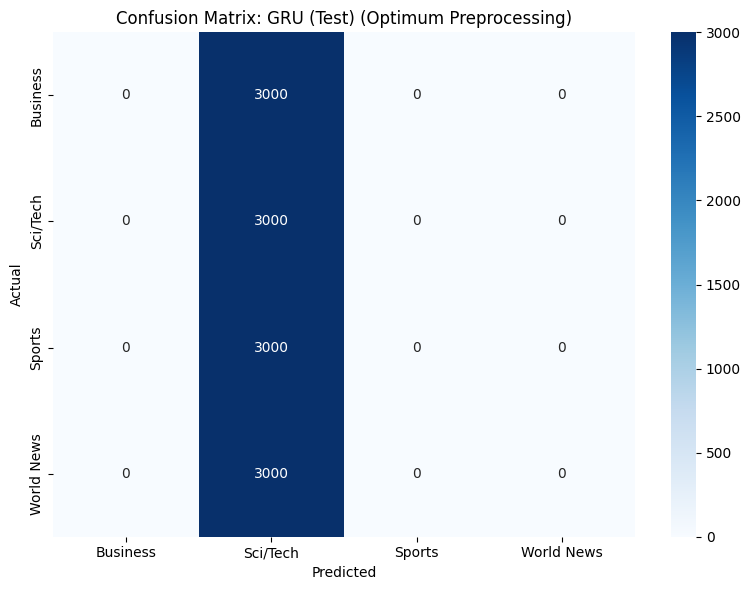

(0.25, 0.1)

In [63]:
# GRU — Optimum Preprocessing
# Fixed: using 64 units + 0.5 dropout (32 units caused model to get stuck at 25%)
td = tokenizer_data['optimum']
vocab_size = embedding_matrices['optimum'].shape[0]

model_GRU_optimum = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['optimum']], trainable=True),
    GRU(64),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model_GRU_optimum.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_GRU_optimum.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_GRU_optimum = model_GRU_optimum.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=128,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_GRU_optimum, 'GRU (Optimum Preprocessing)')

# Evaluate on test set
y_test_pred_GRU_optimum = np.argmax(model_GRU_optimum.predict(td['X_test_seq']), axis=1)
evaluate_model('GRU (Test)', 'Optimum Preprocessing', y_test, y_test_pred_GRU_optimum)

### 9.3 LSTM

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3323 - loss: 1.3242 - val_accuracy: 0.3230 - val_loss: 1.3192
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.4025 - loss: 1.2066 - val_accuracy: 0.8358 - val_loss: 0.4823
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9023 - loss: 0.3169 - val_accuracy: 0.9267 - val_loss: 0.2400
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9401 - loss: 0.2006 - val_accuracy: 0.9354 - val_loss: 0.2132
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9566 - loss: 0.1482 - val_accuracy: 0.9387 - val_loss: 0.2078
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9680 - loss: 0.1094 - val_accuracy: 0.9431 - val_loss: 0.2050
Epoch 7/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9772 - loss: 0.0800 - val_accuracy: 0.9406 - val_loss: 0.2236
Epoch 8/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9842 -

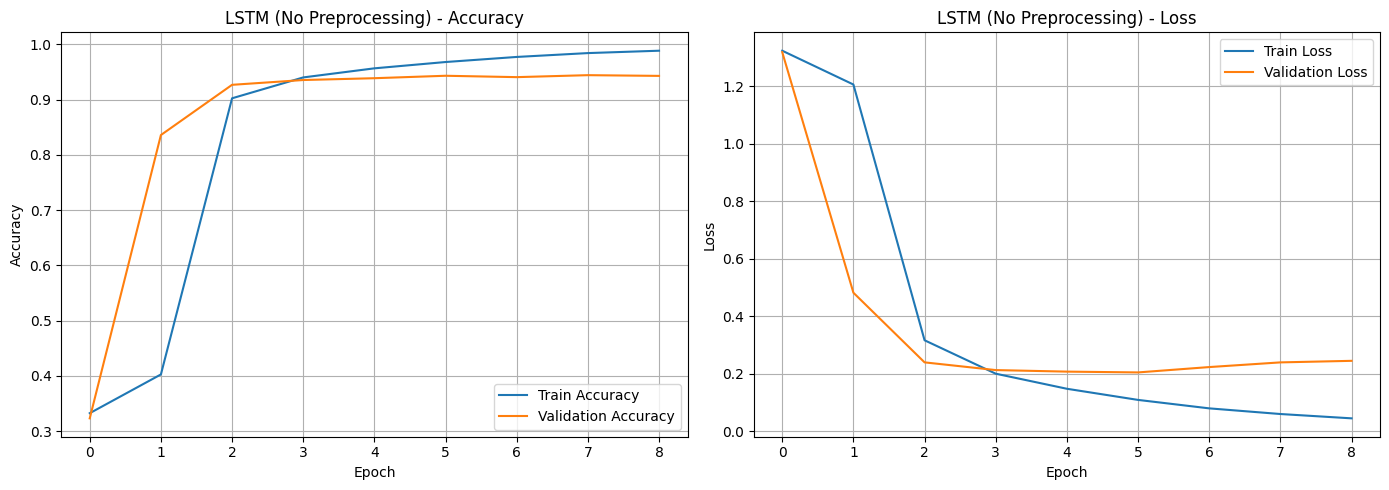

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model: LSTM (Test) | Preprocessing: No Preprocessing
Accuracy: 0.9102
F1-Score (macro): 0.9099

Classification Report:
              precision    recall  f1-score   support

    Business       0.90      0.84      0.87      3000
    Sci/Tech       0.86      0.92      0.89      3000
      Sports       0.96      0.98      0.97      3000
  World News       0.92      0.90      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000



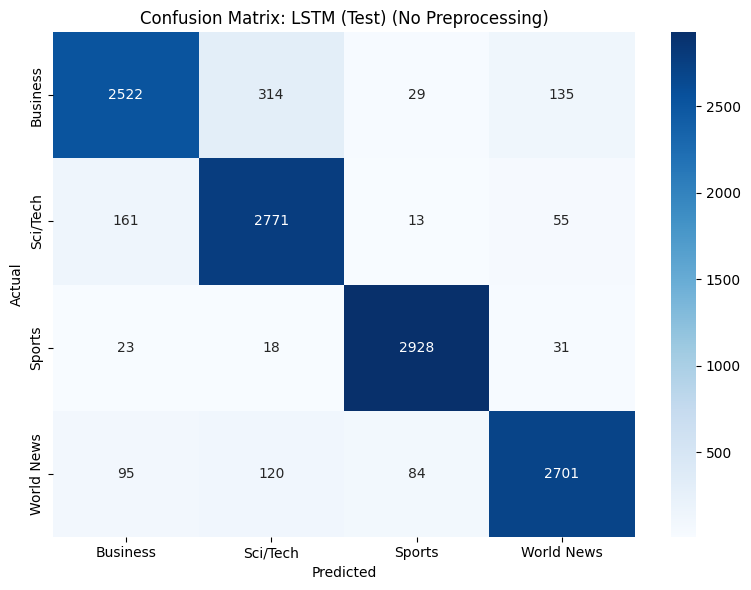

(0.9101666666666667, 0.9098896715410764)

In [64]:
# LSTM — No Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['none']
vocab_size = embedding_matrices['none'].shape[0]

model_LSTM_none = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['none']], trainable=True),
    LSTM(best_rnn_units),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_LSTM_none.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_LSTM_none.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_LSTM_none = model_LSTM_none.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_LSTM_none, 'LSTM (No Preprocessing)')

# Evaluate on test set
y_test_pred_LSTM_none = np.argmax(model_LSTM_none.predict(td['X_test_seq']), axis=1)
evaluate_model('LSTM (Test)', 'No Preprocessing', y_test, y_test_pred_LSTM_none)

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3269 - loss: 1.3252 - val_accuracy: 0.3324 - val_loss: 1.3219
Epoch 2/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3313 - loss: 1.3233 - val_accuracy: 0.3324 - val_loss: 1.3209
Epoch 3/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3293 - loss: 1.3227 - val_accuracy: 0.3195 - val_loss: 1.3224
Epoch 4/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3280 - loss: 1.3223 - val_accuracy: 0.3324 - val_loss: 1.3211
Epoch 5/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3301 - loss: 1.3221 - val_accuracy: 0.3324 - val_loss: 1.3208
Epoch 6/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3310 - loss: 1.3220 - val_accuracy: 0.3324 - val_loss: 1.3209
Epoch 7/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3310 - loss: 1.3213 - val_accuracy: 0.3324 - val_loss: 1.3210
Epoch 8/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3688 - loss: 1.2719 - val_acc

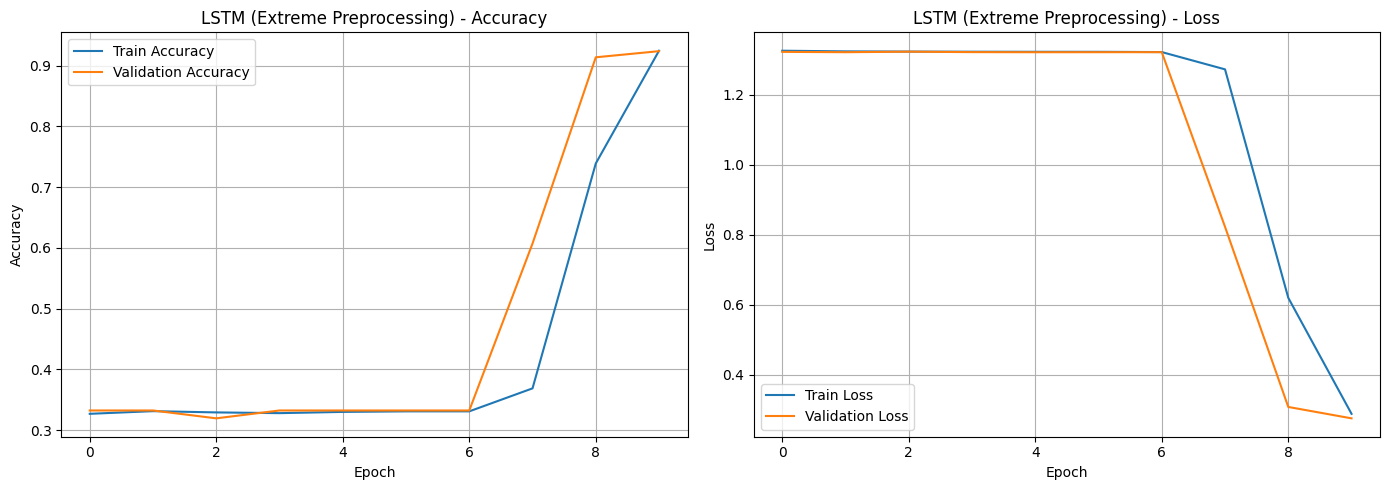

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model: LSTM (Test) | Preprocessing: Extreme Preprocessing
Accuracy: 0.8957
F1-Score (macro): 0.8950

Classification Report:
              precision    recall  f1-score   support

    Business       0.92      0.79      0.85      3000
    Sci/Tech       0.84      0.94      0.89      3000
      Sports       0.96      0.95      0.96      3000
  World News       0.88      0.90      0.89      3000

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.89     12000
weighted avg       0.90      0.90      0.89     12000



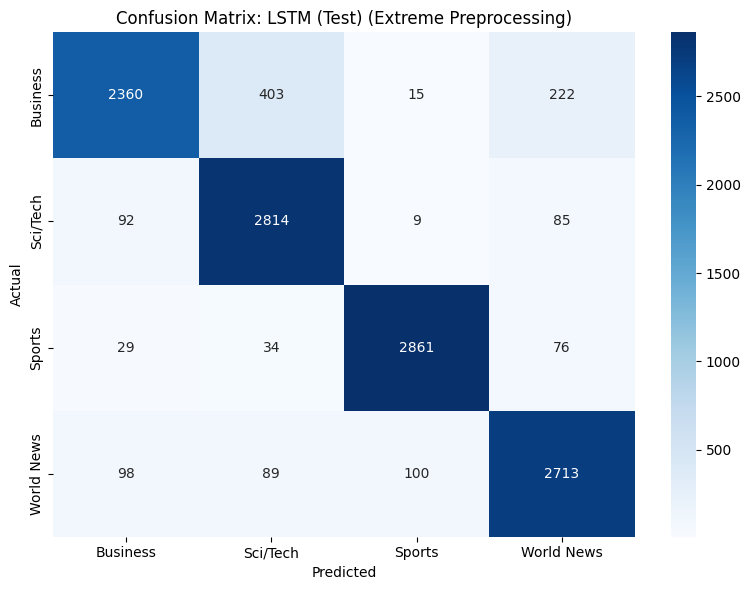

(0.8956666666666667, 0.8949688968812519)

In [65]:
# LSTM — Extreme Preprocessing
# Fixed: using 64 units + 0.5 dropout (32 units caused model to get stuck at 25%)
td = tokenizer_data['extreme']
vocab_size = embedding_matrices['extreme'].shape[0]

model_LSTM_extreme = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['extreme']], trainable=True),
    LSTM(64),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model_LSTM_extreme.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_LSTM_extreme.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_LSTM_extreme = model_LSTM_extreme.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=128,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_LSTM_extreme, 'LSTM (Extreme Preprocessing)')

# Evaluate on test set
y_test_pred_LSTM_extreme = np.argmax(model_LSTM_extreme.predict(td['X_test_seq']), axis=1)
evaluate_model('LSTM (Test)', 'Extreme Preprocessing', y_test, y_test_pred_LSTM_extreme)

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3260 - loss: 1.3253 - val_accuracy: 0.3324 - val_loss: 1.3210
Epoch 2/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3274 - loss: 1.3233 - val_accuracy: 0.3324 - val_loss: 1.3213
Epoch 3/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3306 - loss: 1.3223 - val_accuracy: 0.3324 - val_loss: 1.3213
Epoch 4/10
551/551 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3295 - loss: 1.3221 - val_accuracy: 0.3324 - val_loss: 1.3210


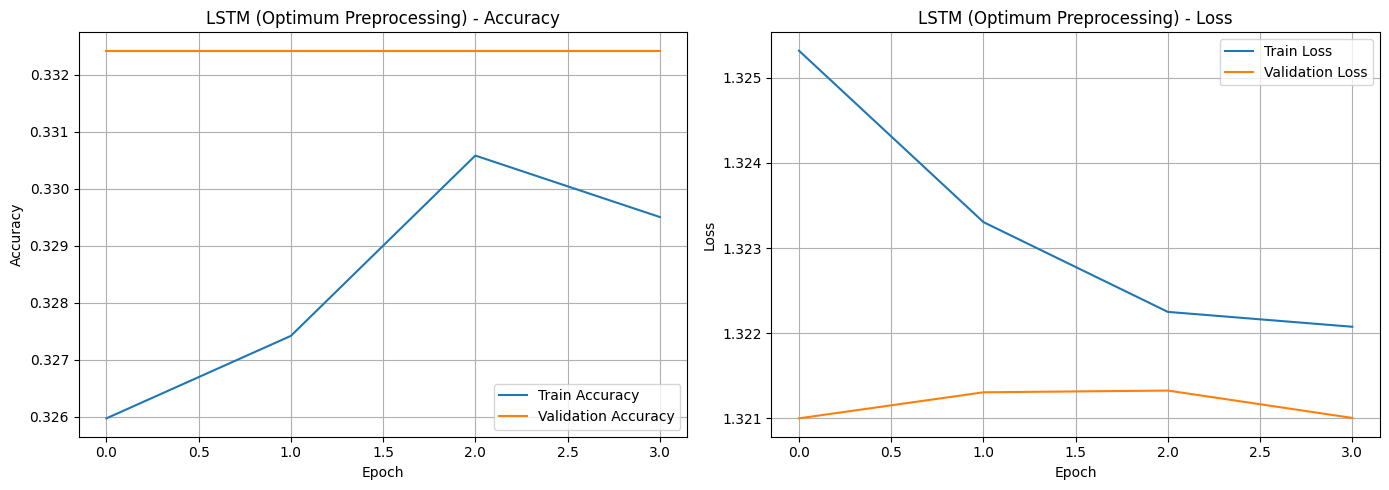

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model: LSTM (Test) | Preprocessing: Optimum Preprocessing
Accuracy: 0.2500
F1-Score (macro): 0.1000

Classification Report:
              precision    recall  f1-score   support

    Business       0.00      0.00      0.00      3000
    Sci/Tech       0.25      1.00      0.40      3000
      Sports       0.00      0.00      0.00      3000
  World News       0.00      0.00      0.00      3000

    accuracy                           0.25     12000
   macro avg       0.06      0.25      0.10     12000
weighted avg       0.06      0.25      0.10     12000



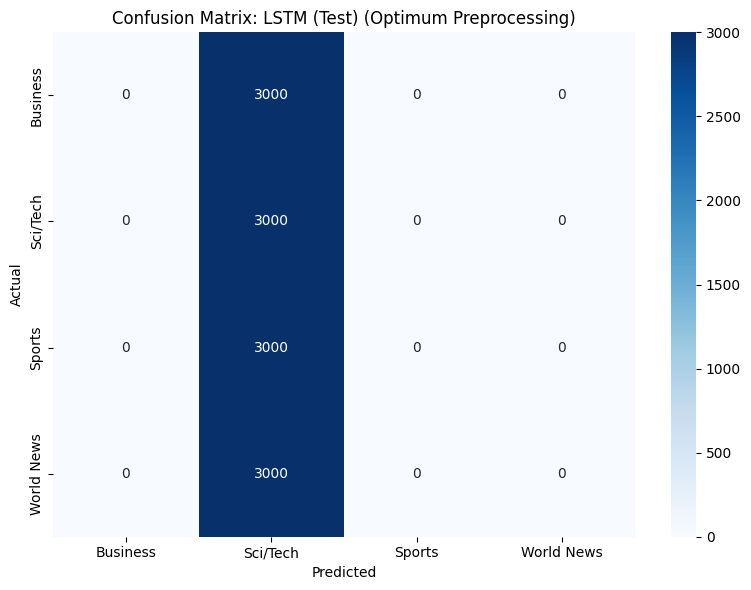

(0.25, 0.1)

In [66]:
# LSTM — Optimum Preprocessing
# Fixed: using 64 units + 0.5 dropout (32 units caused model to get stuck at 25%)
td = tokenizer_data['optimum']
vocab_size = embedding_matrices['optimum'].shape[0]

model_LSTM_optimum = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['optimum']], trainable=True),
    LSTM(64),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model_LSTM_optimum.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_LSTM_optimum.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_LSTM_optimum = model_LSTM_optimum.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=128,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_LSTM_optimum, 'LSTM (Optimum Preprocessing)')

# Evaluate on test set
y_test_pred_LSTM_optimum = np.argmax(model_LSTM_optimum.predict(td['X_test_seq']), axis=1)
evaluate_model('LSTM (Test)', 'Optimum Preprocessing', y_test, y_test_pred_LSTM_optimum)

### 9.4 Bidirectional SimpleRNN

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.8424 - loss: 0.4650 - val_accuracy: 0.8879 - val_loss: 0.3466
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9150 - loss: 0.2730 - val_accuracy: 0.9123 - val_loss: 0.2678
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9368 - loss: 0.2051 - val_accuracy: 0.9276 - val_loss: 0.2531
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9492 - loss: 0.1648 - val_accuracy: 0.9071 - val_loss: 0.3290
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9616 - loss: 0.1270 - val_accuracy: 0.9307 - val_loss: 0.2711
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9677 - loss: 0.1063 - val_accuracy: 0.9251 - val_loss: 0.3129


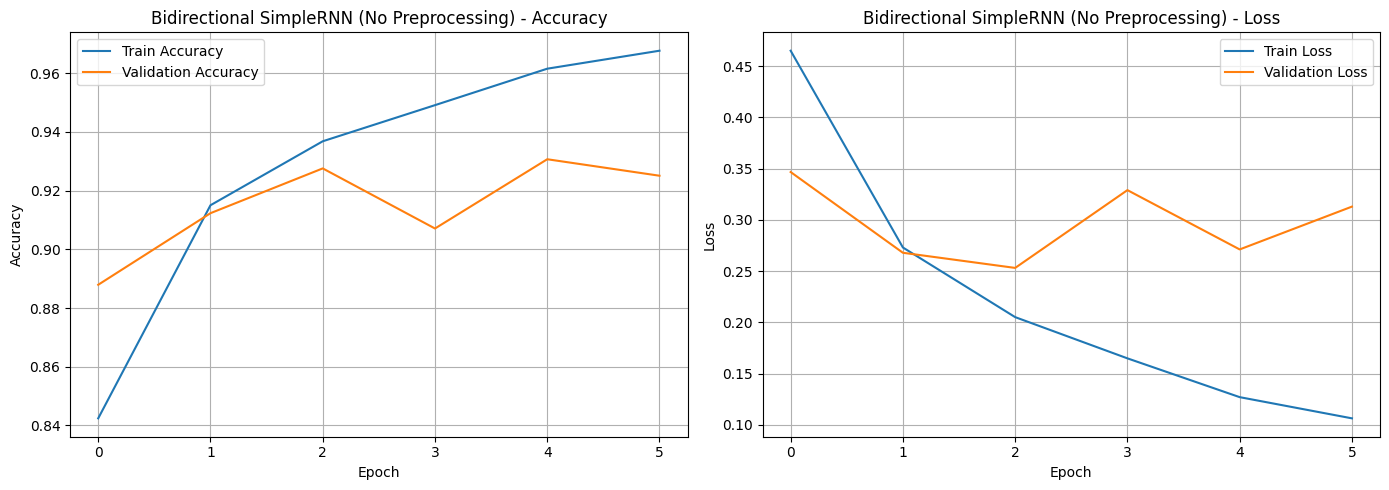

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Model: Bidirectional SimpleRNN (Test) | Preprocessing: No Preprocessing
Accuracy: 0.8938
F1-Score (macro): 0.8933

Classification Report:
              precision    recall  f1-score   support

    Business       0.92      0.79      0.85      3000
    Sci/Tech       0.81      0.94      0.87      3000
      Sports       0.94      0.97      0.95      3000
  World News       0.93      0.88      0.90      3000

    accuracy                           0.89     12000
   macro avg       0.90      0.89      0.89     12000
weighted avg       0.90      0.89      0.89     12000



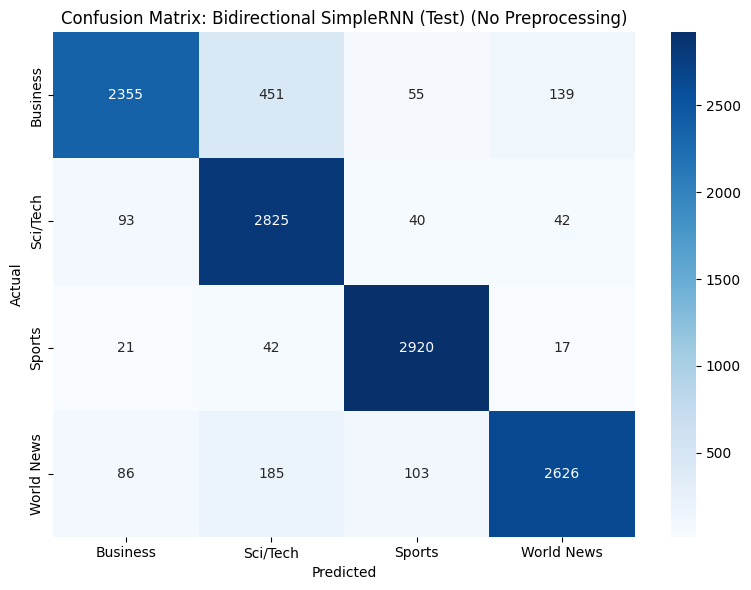

(0.8938333333333334, 0.8932651468668978)

In [67]:
# Bidirectional SimpleRNN — No Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['none']
vocab_size = embedding_matrices['none'].shape[0]

model_BiSimpleRNN_none = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['none']], trainable=True),
    Bidirectional(SimpleRNN(best_rnn_units)),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_BiSimpleRNN_none.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_BiSimpleRNN_none.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_BiSimpleRNN_none = model_BiSimpleRNN_none.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_BiSimpleRNN_none, 'Bidirectional SimpleRNN (No Preprocessing)')

# Evaluate on test set
y_test_pred_BiSimpleRNN_none = np.argmax(model_BiSimpleRNN_none.predict(td['X_test_seq']), axis=1)
evaluate_model('Bidirectional SimpleRNN (Test)', 'No Preprocessing', y_test, y_test_pred_BiSimpleRNN_none)

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.8798 - loss: 0.3695 - val_accuracy: 0.9186 - val_loss: 0.2761
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9280 - loss: 0.2320 - val_accuracy: 0.9235 - val_loss: 0.2522
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9450 - loss: 0.1771 - val_accuracy: 0.9339 - val_loss: 0.2260
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9545 - loss: 0.1470 - val_accuracy: 0.9270 - val_loss: 0.2459
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9612 - loss: 0.1209 - val_accuracy: 0.9358 - val_loss: 0.2427
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9703 - loss: 0.0942 - val_accuracy: 0.9368 - val_loss: 0.2544


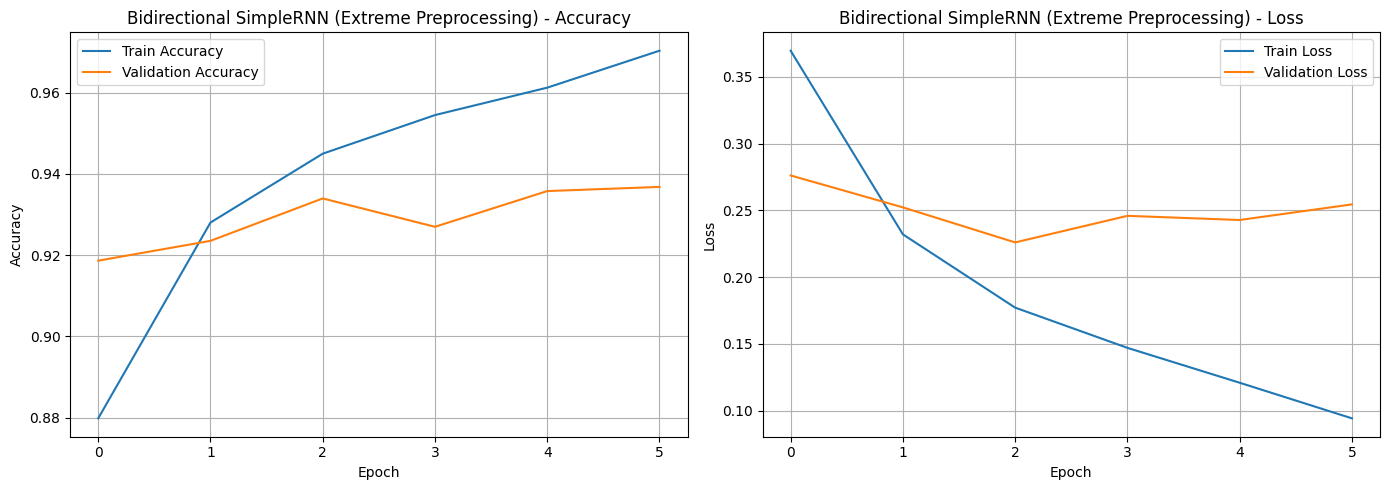

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model: Bidirectional SimpleRNN (Test) | Preprocessing: Extreme Preprocessing
Accuracy: 0.9032
F1-Score (macro): 0.9029

Classification Report:
              precision    recall  f1-score   support

    Business       0.91      0.81      0.86      3000
    Sci/Tech       0.83      0.94      0.88      3000
      Sports       0.96      0.97      0.96      3000
  World News       0.93      0.90      0.91      3000

    accuracy                           0.90     12000
   macro avg       0.91      0.90      0.90     12000
weighted avg       0.91      0.90      0.90     12000



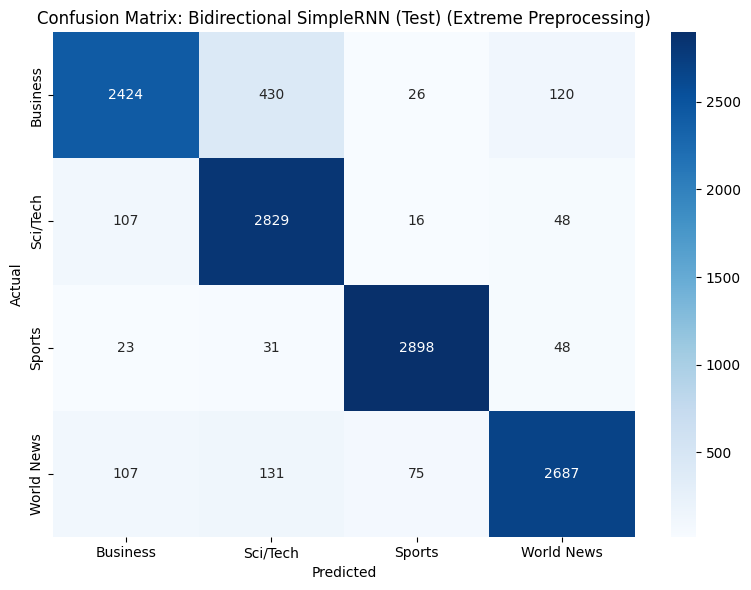

(0.9031666666666667, 0.902883131843872)

In [68]:
# Bidirectional SimpleRNN — Extreme Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['extreme']
vocab_size = embedding_matrices['extreme'].shape[0]

model_BiSimpleRNN_extreme = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['extreme']], trainable=True),
    Bidirectional(SimpleRNN(best_rnn_units)),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_BiSimpleRNN_extreme.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_BiSimpleRNN_extreme.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_BiSimpleRNN_extreme = model_BiSimpleRNN_extreme.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_BiSimpleRNN_extreme, 'Bidirectional SimpleRNN (Extreme Preprocessing)')

# Evaluate on test set
y_test_pred_BiSimpleRNN_extreme = np.argmax(model_BiSimpleRNN_extreme.predict(td['X_test_seq']), axis=1)
evaluate_model('Bidirectional SimpleRNN (Test)', 'Extreme Preprocessing', y_test, y_test_pred_BiSimpleRNN_extreme)

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.8837 - loss: 0.3596 - val_accuracy: 0.9127 - val_loss: 0.2828
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9267 - loss: 0.2384 - val_accuracy: 0.9217 - val_loss: 0.2533
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9416 - loss: 0.1882 - val_accuracy: 0.9269 - val_loss: 0.2461
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9572 - loss: 0.1401 - val_accuracy: 0.9344 - val_loss: 0.2456
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9650 - loss: 0.1118 - val_accuracy: 0.9316 - val_loss: 0.2640
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9727 - loss: 0.0868 - val_accuracy: 0.9350 - val_loss: 0.2576
Epoch 7/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9762 - loss: 0.0751 - val_accuracy: 0.9316 - val_loss: 0.2986


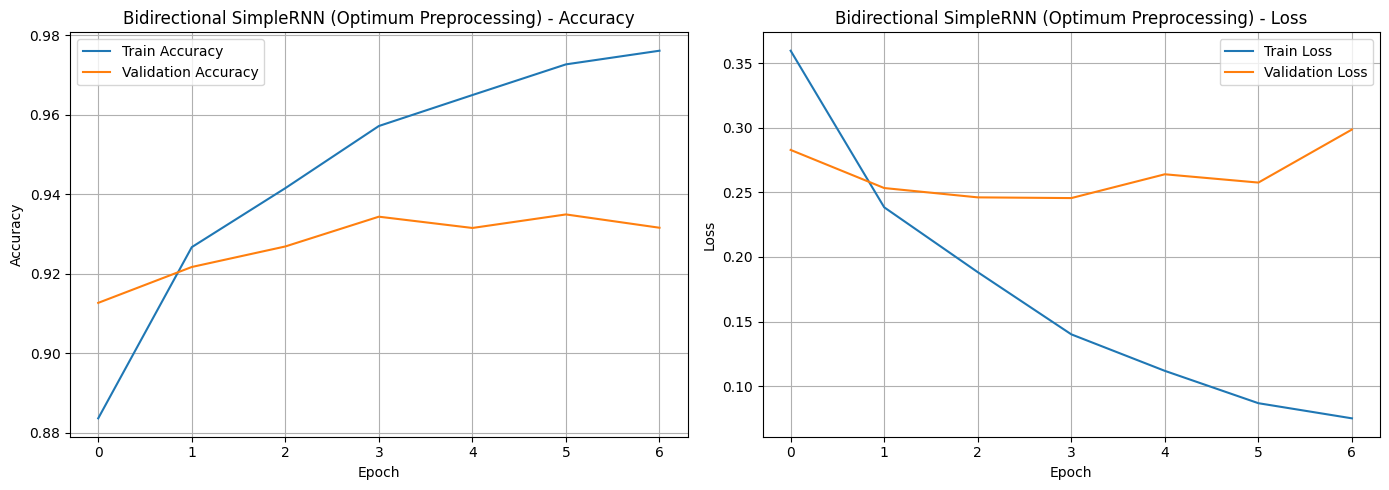

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Model: Bidirectional SimpleRNN (Test) | Preprocessing: Optimum Preprocessing
Accuracy: 0.9038
F1-Score (macro): 0.9031

Classification Report:
              precision    recall  f1-score   support

    Business       0.91      0.81      0.86      3000
    Sci/Tech       0.86      0.91      0.88      3000
      Sports       0.95      0.98      0.96      3000
  World News       0.90      0.91      0.91      3000

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000



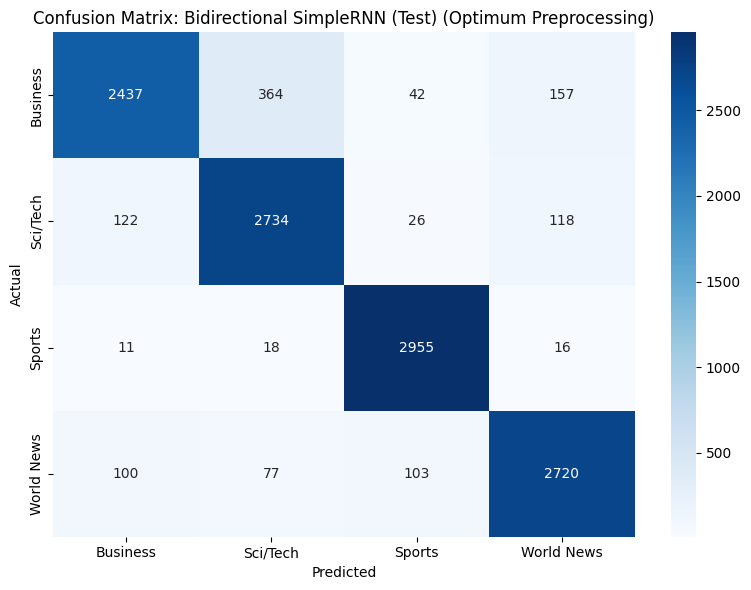

(0.9038333333333334, 0.9030730681817608)

In [69]:
# Bidirectional SimpleRNN — Optimum Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['optimum']
vocab_size = embedding_matrices['optimum'].shape[0]

model_BiSimpleRNN_optimum = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['optimum']], trainable=True),
    Bidirectional(SimpleRNN(best_rnn_units)),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_BiSimpleRNN_optimum.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_BiSimpleRNN_optimum.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_BiSimpleRNN_optimum = model_BiSimpleRNN_optimum.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_BiSimpleRNN_optimum, 'Bidirectional SimpleRNN (Optimum Preprocessing)')

# Evaluate on test set
y_test_pred_BiSimpleRNN_optimum = np.argmax(model_BiSimpleRNN_optimum.predict(td['X_test_seq']), axis=1)
evaluate_model('Bidirectional SimpleRNN (Test)', 'Optimum Preprocessing', y_test, y_test_pred_BiSimpleRNN_optimum)

### 9.5 Bidirectional GRU

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8860 - loss: 0.3300 - val_accuracy: 0.9343 - val_loss: 0.2014
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9476 - loss: 0.1628 - val_accuracy: 0.9439 - val_loss: 0.1751
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9648 - loss: 0.1077 - val_accuracy: 0.9417 - val_loss: 0.1820
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9765 - loss: 0.0741 - val_accuracy: 0.9413 - val_loss: 0.2138
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9843 - loss: 0.0501 - val_accuracy: 0.9431 - val_loss: 0.2231


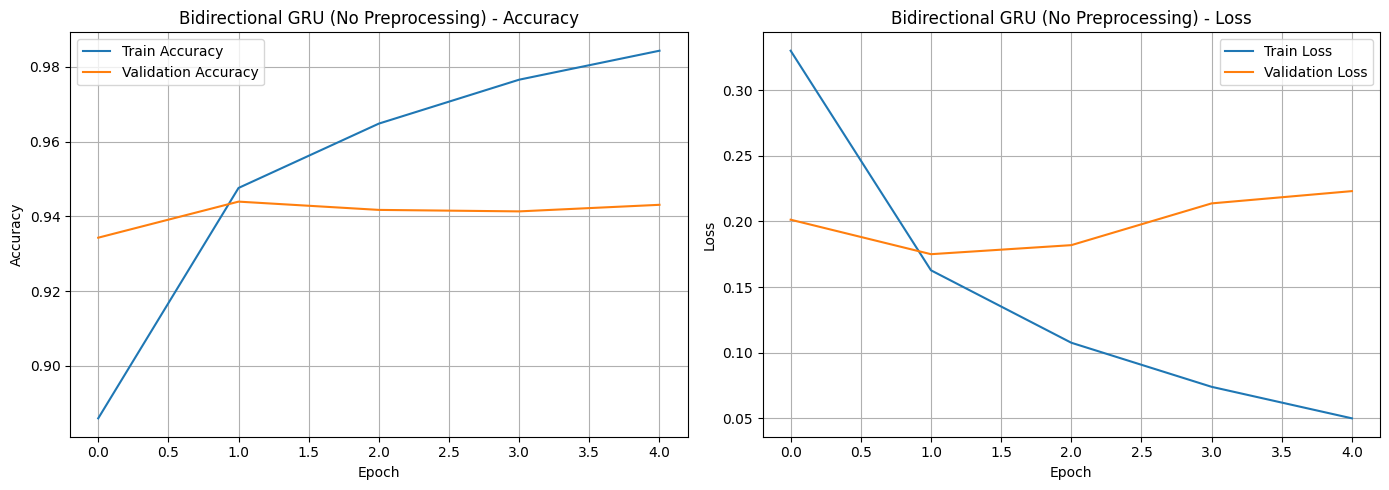

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model: Bidirectional GRU (Test) | Preprocessing: No Preprocessing
Accuracy: 0.9177
F1-Score (macro): 0.9172

Classification Report:
              precision    recall  f1-score   support

    Business       0.93      0.84      0.88      3000
    Sci/Tech       0.88      0.93      0.90      3000
      Sports       0.95      0.98      0.97      3000
  World News       0.92      0.91      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



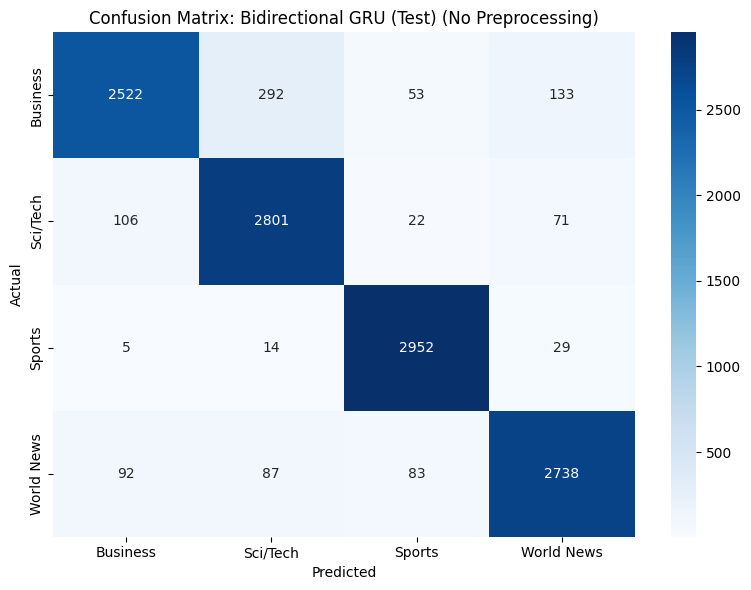

(0.91775, 0.9172139407774101)

In [70]:
# Bidirectional GRU — No Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['none']
vocab_size = embedding_matrices['none'].shape[0]

model_BiGRU_none = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['none']], trainable=True),
    Bidirectional(GRU(best_rnn_units)),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_BiGRU_none.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_BiGRU_none.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_BiGRU_none = model_BiGRU_none.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_BiGRU_none, 'Bidirectional GRU (No Preprocessing)')

# Evaluate on test set
y_test_pred_BiGRU_none = np.argmax(model_BiGRU_none.predict(td['X_test_seq']), axis=1)
evaluate_model('Bidirectional GRU (Test)', 'No Preprocessing', y_test, y_test_pred_BiGRU_none)

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.9048 - loss: 0.2861 - val_accuracy: 0.9288 - val_loss: 0.2152
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9430 - loss: 0.1749 - val_accuracy: 0.9383 - val_loss: 0.1939
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9606 - loss: 0.1224 - val_accuracy: 0.9392 - val_loss: 0.1874
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9728 - loss: 0.0853 - val_accuracy: 0.9407 - val_loss: 0.2058
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9815 - loss: 0.0561 - val_accuracy: 0.9428 - val_loss: 0.2294
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9874 - loss: 0.0382 - val_accuracy: 0.9429 - val_loss: 0.2591


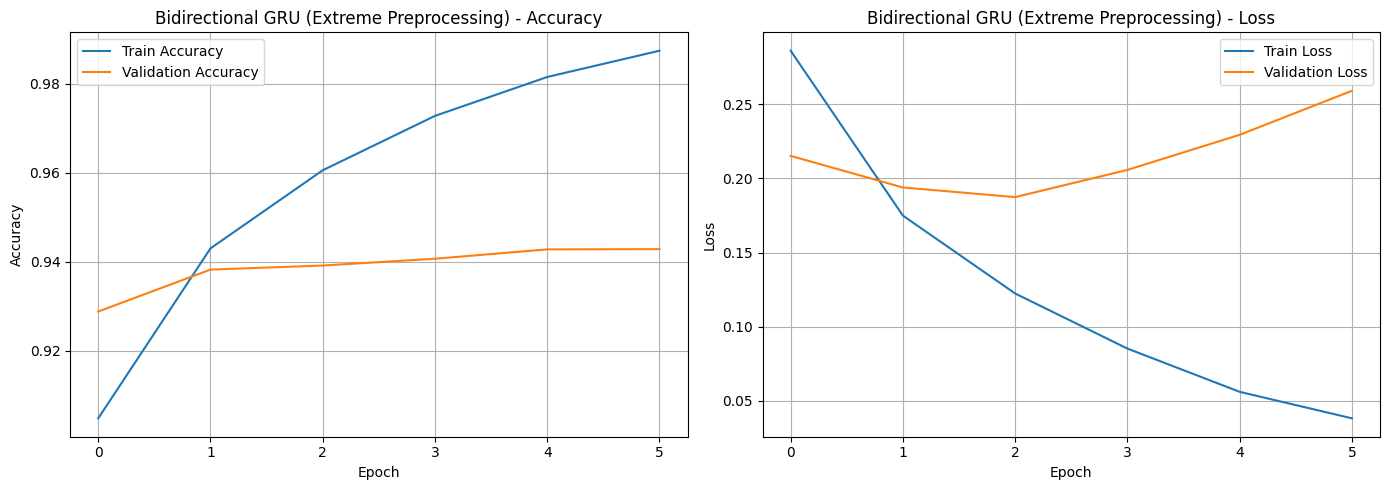

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model: Bidirectional GRU (Test) | Preprocessing: Extreme Preprocessing
Accuracy: 0.9167
F1-Score (macro): 0.9166

Classification Report:
              precision    recall  f1-score   support

    Business       0.88      0.89      0.89      3000
    Sci/Tech       0.89      0.90      0.90      3000
      Sports       0.96      0.98      0.97      3000
  World News       0.93      0.90      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



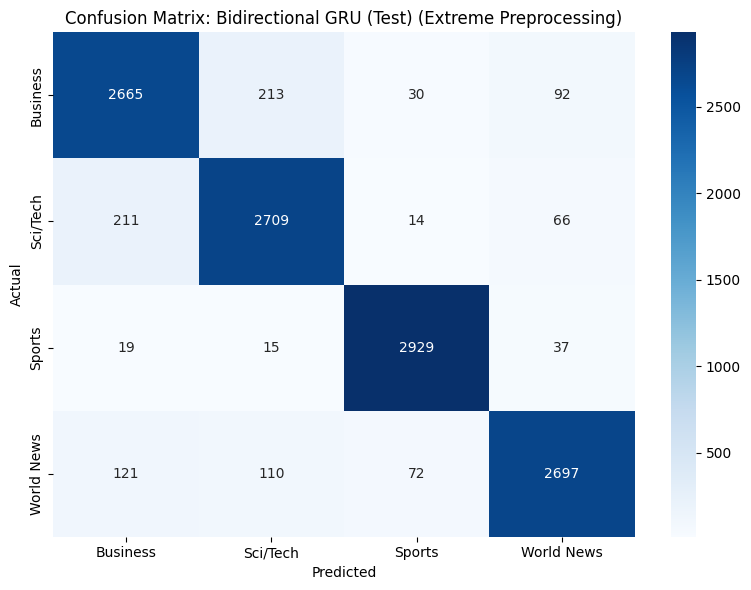

(0.9166666666666666, 0.9166240453575191)

In [71]:
# Bidirectional GRU — Extreme Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['extreme']
vocab_size = embedding_matrices['extreme'].shape[0]

model_BiGRU_extreme = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['extreme']], trainable=True),
    Bidirectional(GRU(best_rnn_units)),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_BiGRU_extreme.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_BiGRU_extreme.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_BiGRU_extreme = model_BiGRU_extreme.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_BiGRU_extreme, 'Bidirectional GRU (Extreme Preprocessing)')

# Evaluate on test set
y_test_pred_BiGRU_extreme = np.argmax(model_BiGRU_extreme.predict(td['X_test_seq']), axis=1)
evaluate_model('Bidirectional GRU (Test)', 'Extreme Preprocessing', y_test, y_test_pred_BiGRU_extreme)

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9043 - loss: 0.2866 - val_accuracy: 0.9330 - val_loss: 0.2042
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9447 - loss: 0.1680 - val_accuracy: 0.9404 - val_loss: 0.1867
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9634 - loss: 0.1140 - val_accuracy: 0.9453 - val_loss: 0.1881
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9763 - loss: 0.0732 - val_accuracy: 0.9425 - val_loss: 0.2083
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9844 - loss: 0.0487 - val_accuracy: 0.9435 - val_loss: 0.2297


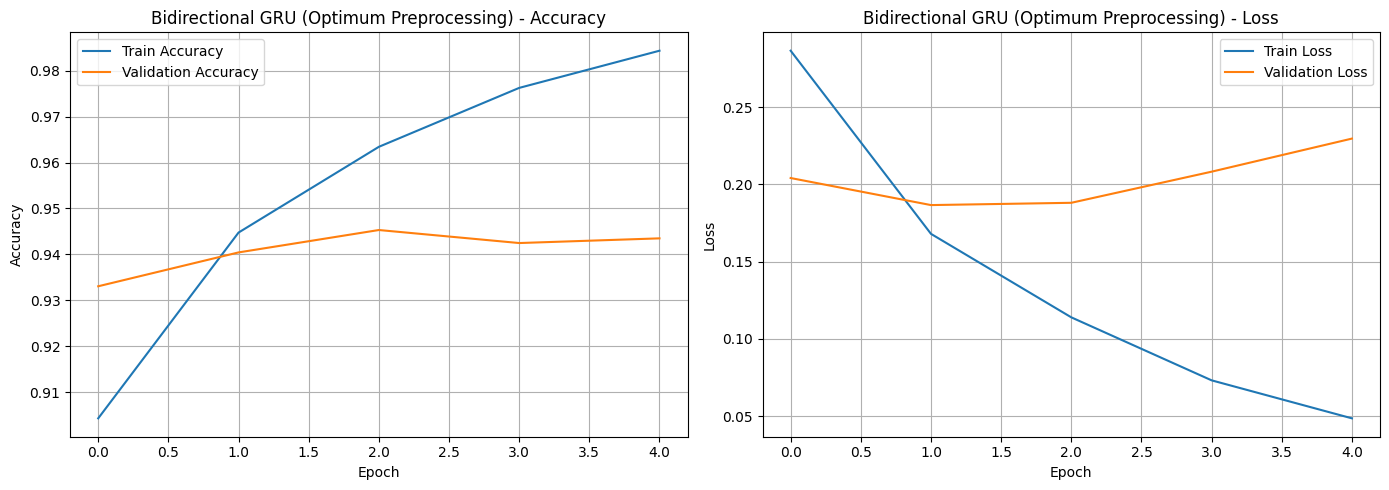

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model: Bidirectional GRU (Test) | Preprocessing: Optimum Preprocessing
Accuracy: 0.9193
F1-Score (macro): 0.9189

Classification Report:
              precision    recall  f1-score   support

    Business       0.91      0.86      0.88      3000
    Sci/Tech       0.88      0.93      0.90      3000
      Sports       0.96      0.99      0.97      3000
  World News       0.93      0.91      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



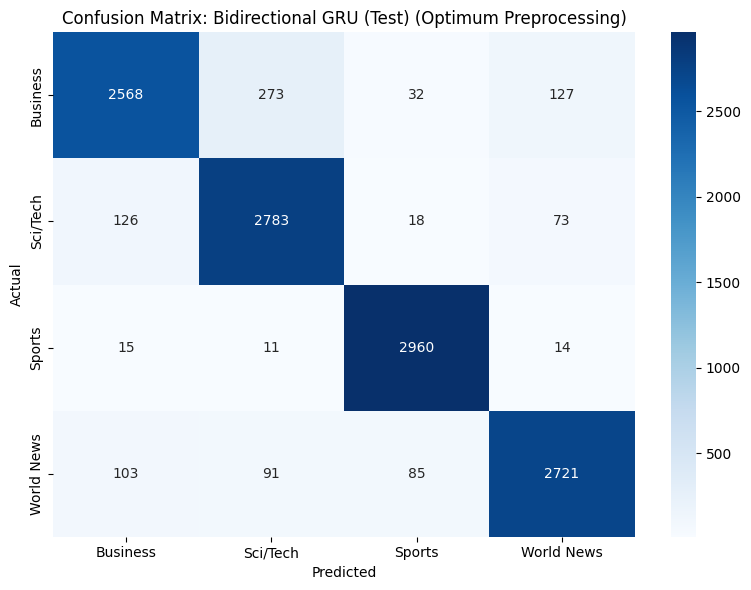

(0.9193333333333333, 0.9189437993179773)

In [72]:
# Bidirectional GRU — Optimum Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['optimum']
vocab_size = embedding_matrices['optimum'].shape[0]

model_BiGRU_optimum = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['optimum']], trainable=True),
    Bidirectional(GRU(best_rnn_units)),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_BiGRU_optimum.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_BiGRU_optimum.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_BiGRU_optimum = model_BiGRU_optimum.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_BiGRU_optimum, 'Bidirectional GRU (Optimum Preprocessing)')

# Evaluate on test set
y_test_pred_BiGRU_optimum = np.argmax(model_BiGRU_optimum.predict(td['X_test_seq']), axis=1)
evaluate_model('Bidirectional GRU (Test)', 'Optimum Preprocessing', y_test, y_test_pred_BiGRU_optimum)

### 9.6 Bidirectional LSTM

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_24 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8889 - loss: 0.3319 - val_accuracy: 0.9303 - val_loss: 0.2190
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9458 - loss: 0.1689 - val_accuracy: 0.9413 - val_loss: 0.1874
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9633 - loss: 0.1135 - val_accuracy: 0.9418 - val_loss: 0.1923
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9747 - loss: 0.0793 - val_accuracy: 0.9463 - val_loss: 0.1784
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9824 - loss: 0.0568 - val_accuracy: 0.9435 - val_loss: 0.2317
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9874 - loss: 0.0399 - val_accuracy: 0.9409 - val_loss: 0.2392
Epoch 7/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9914 - loss: 0.0275 - val_accuracy: 0.9431 - val_loss: 0.2692


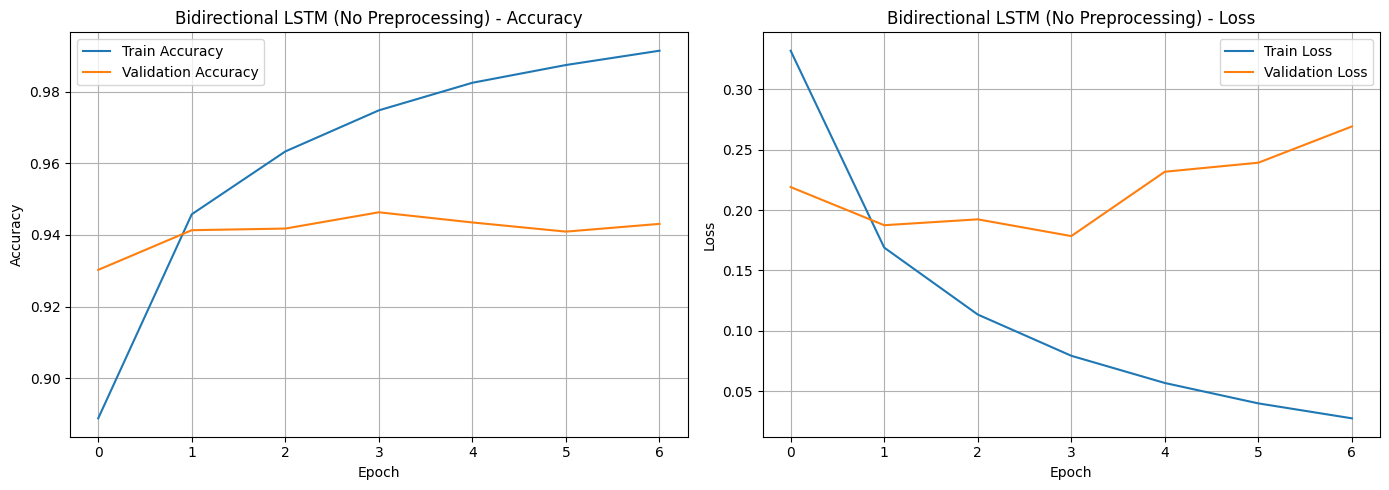

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model: Bidirectional LSTM (Test) | Preprocessing: No Preprocessing
Accuracy: 0.9136
F1-Score (macro): 0.9131

Classification Report:
              precision    recall  f1-score   support

    Business       0.93      0.83      0.88      3000
    Sci/Tech       0.85      0.93      0.89      3000
      Sports       0.95      0.98      0.97      3000
  World News       0.92      0.91      0.92      3000

    accuracy                           0.91     12000
   macro avg       0.92      0.91      0.91     12000
weighted avg       0.92      0.91      0.91     12000



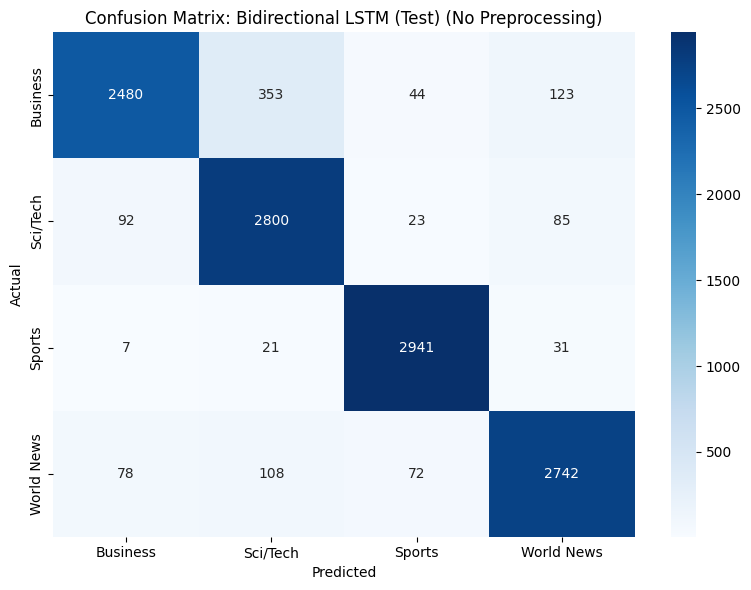

(0.9135833333333333, 0.9131408511862676)

In [73]:
# Bidirectional LSTM — No Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['none']
vocab_size = embedding_matrices['none'].shape[0]

model_BiLSTM_none = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['none']], trainable=True),
    Bidirectional(LSTM(best_rnn_units)),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_BiLSTM_none.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_BiLSTM_none.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_BiLSTM_none = model_BiLSTM_none.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_BiLSTM_none, 'Bidirectional LSTM (No Preprocessing)')

# Evaluate on test set
y_test_pred_BiLSTM_none = np.argmax(model_BiLSTM_none.predict(td['X_test_seq']), axis=1)
evaluate_model('Bidirectional LSTM (Test)', 'No Preprocessing', y_test, y_test_pred_BiLSTM_none)

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_25 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9067 - loss: 0.2820 - val_accuracy: 0.9314 - val_loss: 0.2089
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9427 - loss: 0.1748 - val_accuracy: 0.9360 - val_loss: 0.1920
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9600 - loss: 0.1226 - val_accuracy: 0.9452 - val_loss: 0.1872
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9721 - loss: 0.0871 - val_accuracy: 0.9440 - val_loss: 0.1975
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9792 - loss: 0.0628 - val_accuracy: 0.9451 - val_loss: 0.2244
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9858 - loss: 0.0438 - val_accuracy: 0.9465 - val_loss: 0.2271


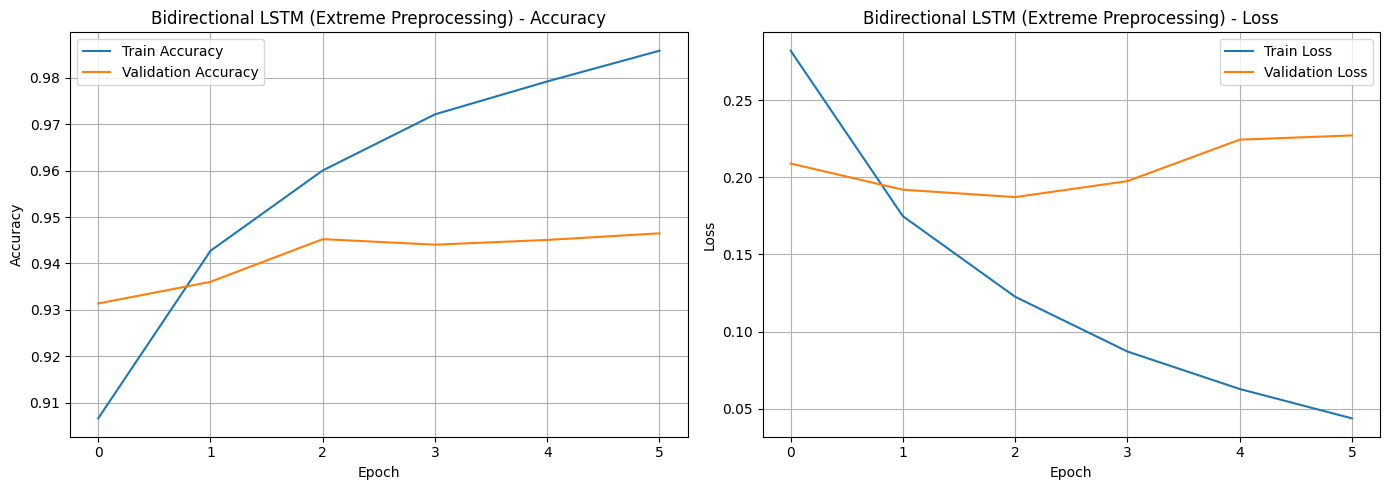

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model: Bidirectional LSTM (Test) | Preprocessing: Extreme Preprocessing
Accuracy: 0.9190
F1-Score (macro): 0.9185

Classification Report:
              precision    recall  f1-score   support

    Business       0.93      0.83      0.88      3000
    Sci/Tech       0.86      0.94      0.90      3000
      Sports       0.95      0.99      0.97      3000
  World News       0.94      0.91      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



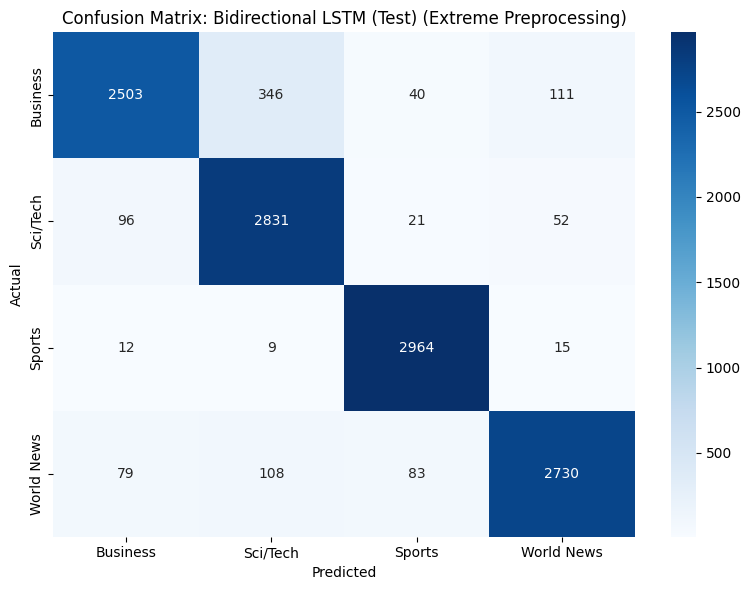

(0.919, 0.9185192699593355)

In [74]:
# Bidirectional LSTM — Extreme Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['extreme']
vocab_size = embedding_matrices['extreme'].shape[0]

model_BiLSTM_extreme = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['extreme']], trainable=True),
    Bidirectional(LSTM(best_rnn_units)),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_BiLSTM_extreme.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_BiLSTM_extreme.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_BiLSTM_extreme = model_BiLSTM_extreme.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_BiLSTM_extreme, 'Bidirectional LSTM (Extreme Preprocessing)')

# Evaluate on test set
y_test_pred_BiLSTM_extreme = np.argmax(model_BiLSTM_extreme.predict(td['X_test_seq']), axis=1)
evaluate_model('Bidirectional LSTM (Test)', 'Extreme Preprocessing', y_test, y_test_pred_BiLSTM_extreme)

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_26 (Embedding)        │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.9061 - loss: 0.2829 - val_accuracy: 0.9301 - val_loss: 0.2145
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.9436 - loss: 0.1710 - val_accuracy: 0.9397 - val_loss: 0.1833
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9622 - loss: 0.1159 - val_accuracy: 0.9436 - val_loss: 0.1767
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9754 - loss: 0.0777 - val_accuracy: 0.9457 - val_loss: 0.2115
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9824 - loss: 0.0524 - val_accuracy: 0.9478 - val_loss: 0.2182
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9890 - loss: 0.0344 - val_accuracy: 0.9497 - val_loss: 0.2612


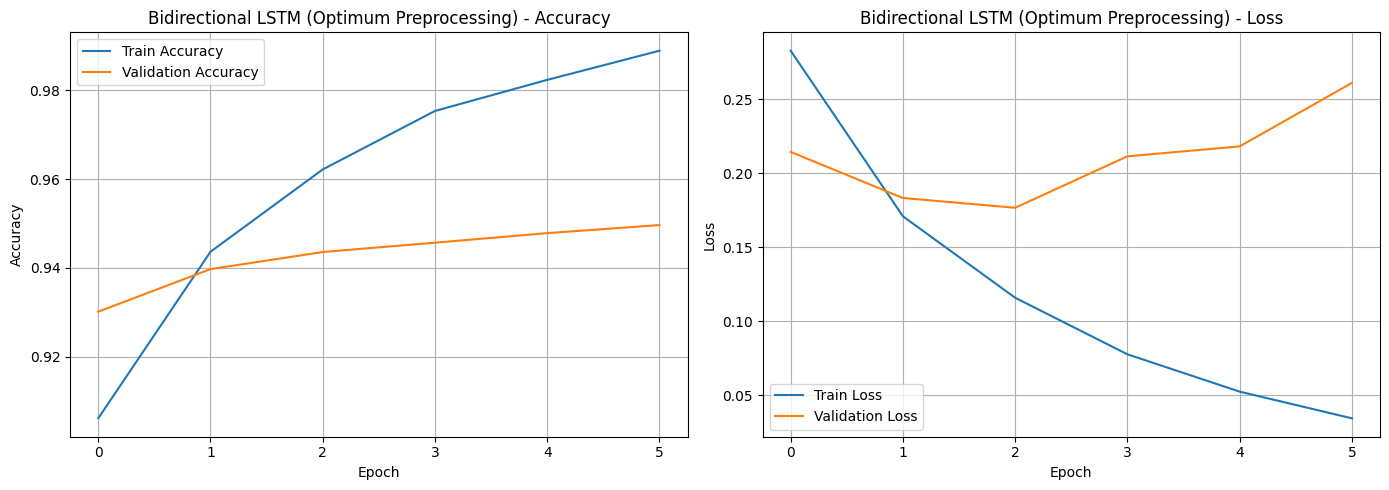

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model: Bidirectional LSTM (Test) | Preprocessing: Optimum Preprocessing
Accuracy: 0.9088
F1-Score (macro): 0.9085

Classification Report:
              precision    recall  f1-score   support

    Business       0.93      0.81      0.87      3000
    Sci/Tech       0.83      0.96      0.89      3000
      Sports       0.97      0.96      0.97      3000
  World News       0.92      0.91      0.91      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000



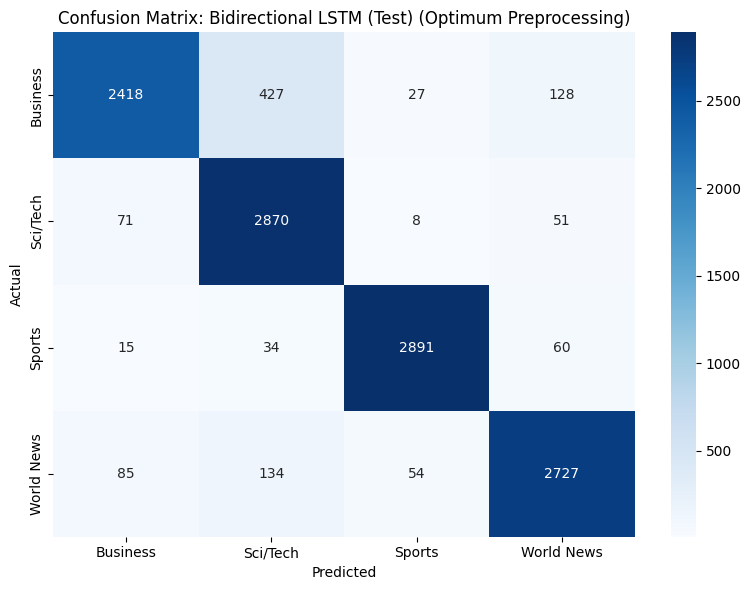

(0.9088333333333334, 0.9085496877264744)

In [75]:
# Bidirectional LSTM — Optimum Preprocessing
# Using best hyperparameters from tuning (Section 5.5)
td = tokenizer_data['optimum']
vocab_size = embedding_matrices['optimum'].shape[0]

model_BiLSTM_optimum = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embedding_matrices['optimum']], trainable=True),
    Bidirectional(LSTM(best_rnn_units)),
    Dropout(best_rnn_dropout),
    Dense(4, activation='softmax')
])

model_BiLSTM_optimum.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_BiLSTM_optimum.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_BiLSTM_optimum = model_BiLSTM_optimum.fit(
    td['X_train_seq'], y_train,
    epochs=10,
    batch_size=best_rnn_batch,
    validation_data=(td['X_val_seq'], y_val),
    callbacks=[early_stop],
    verbose=1
)

plot_training_history(history_BiLSTM_optimum, 'Bidirectional LSTM (Optimum Preprocessing)')

# Evaluate on test set
y_test_pred_BiLSTM_optimum = np.argmax(model_BiLSTM_optimum.predict(td['X_test_seq']), axis=1)
evaluate_model('Bidirectional LSTM (Test)', 'Optimum Preprocessing', y_test, y_test_pred_BiLSTM_optimum)

## 10. Comprehensive Results Comparison
We compile all results and identify the best and worst performing models.

In [76]:
# Re-import essentials (safe to re-run if runtime restarted)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, gc, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [77]:
# Results summary table
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("COMPLETE RESULTS TABLE (Sorted by F1-Score)")
print("="*80)
print(results_df.to_string(index=True))

# Save results
results_df.to_csv('results_summary.csv', index=False)


COMPLETE RESULTS TABLE (Sorted by F1-Score)
                                  Model          Preprocessing  Accuracy  F1-Score
0          TF-IDF + Logistic Regression  Optimum Preprocessing  0.949949  0.937364
1          TF-IDF + Logistic Regression       No Preprocessing  0.948871  0.935410
2          TF-IDF + Logistic Regression  Extreme Preprocessing  0.948247  0.935058
3              Bidirectional GRU (Test)  Optimum Preprocessing  0.919333  0.918944
4             Bidirectional LSTM (Test)  Extreme Preprocessing  0.919000  0.918519
5                            GRU (Test)       No Preprocessing  0.918667  0.918271
6              Bidirectional GRU (Test)       No Preprocessing  0.917750  0.917214
7              Bidirectional GRU (Test)  Extreme Preprocessing  0.916667  0.916624
8   TF-IDF + Logistic Regression (Test)  Extreme Preprocessing  0.913750  0.913195
9             Bidirectional LSTM (Test)       No Preprocessing  0.913583  0.913141
10  TF-IDF + Logistic Regression (Test)  O

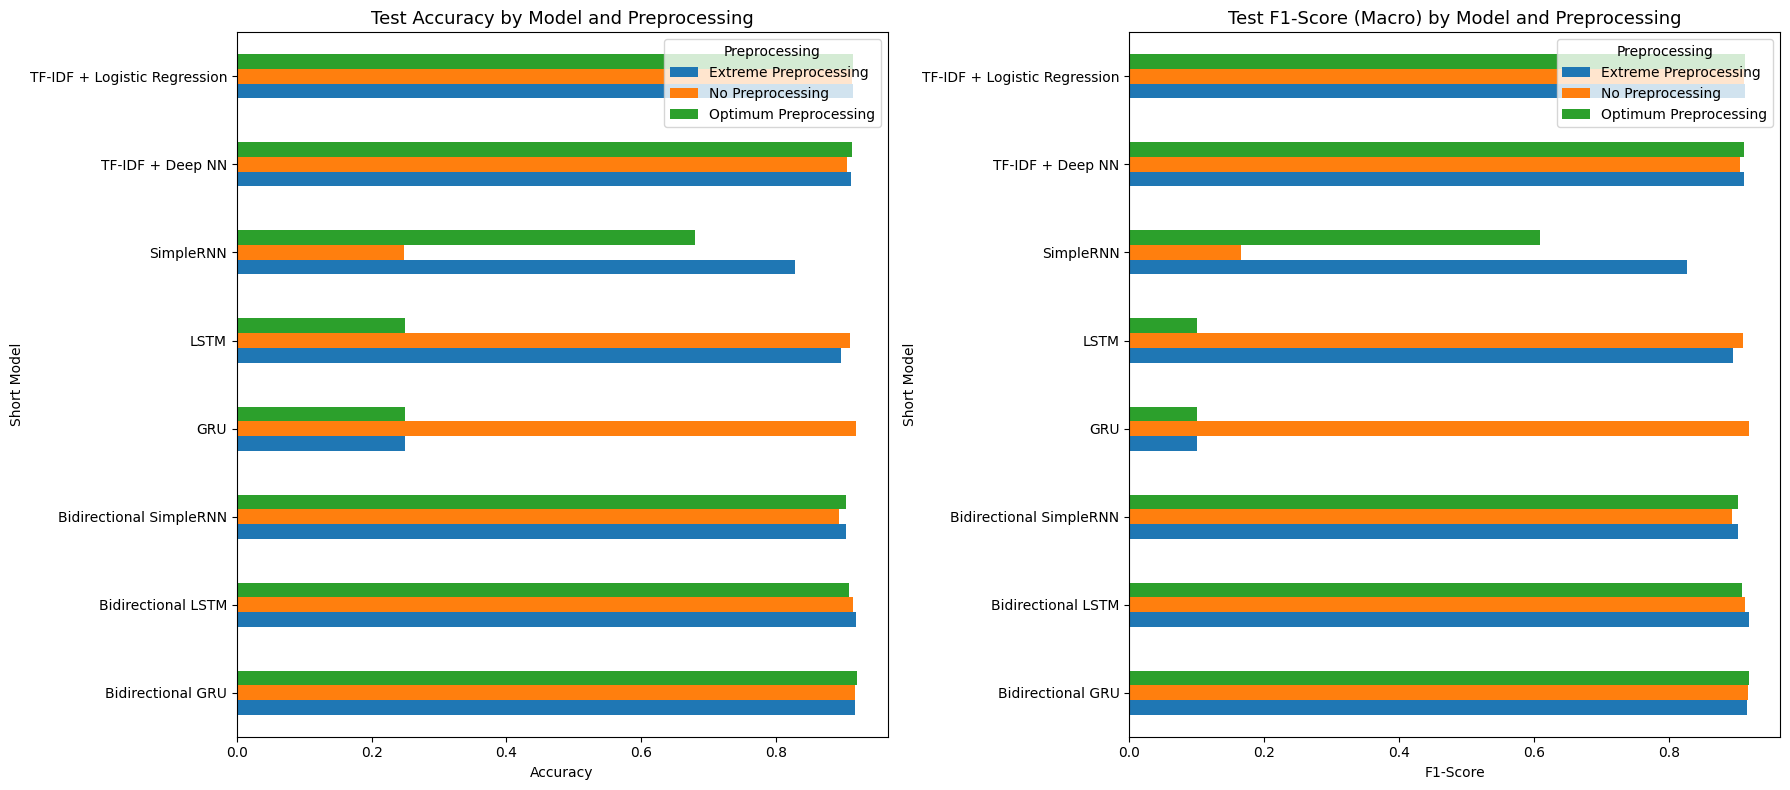

In [78]:
# Visualization: Accuracy and F1-Score comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Filter test results only
test_results = results_df[results_df['Model'].str.contains('Test')].copy()
test_results['Short Model'] = test_results['Model'].str.replace(' (Test)', '', regex=False)

# Accuracy
pivot_acc = test_results.pivot(index='Short Model', columns='Preprocessing', values='Accuracy')
pivot_acc.plot(kind='barh', ax=axes[0])
axes[0].set_title('Test Accuracy by Model and Preprocessing', fontsize=13)
axes[0].set_xlabel('Accuracy')
axes[0].legend(title='Preprocessing')

# F1-Score
pivot_f1 = test_results.pivot(index='Short Model', columns='Preprocessing', values='F1-Score')
pivot_f1.plot(kind='barh', ax=axes[1])
axes[1].set_title('Test F1-Score (Macro) by Model and Preprocessing', fontsize=13)
axes[1].set_xlabel('F1-Score')
axes[1].legend(title='Preprocessing')

plt.tight_layout()
plt.show()

In [79]:
# Best and worst models
print("\n" + "="*60)
print("BEST PERFORMING MODEL (Test Set):")
print("="*60)
best = test_results.loc[test_results['F1-Score'].idxmax()]
print(f"Model: {best['Model']}")
print(f"Preprocessing: {best['Preprocessing']}")
print(f"Accuracy: {best['Accuracy']:.4f}")
print(f"F1-Score: {best['F1-Score']:.4f}")

print("\n" + "="*60)
print("WORST PERFORMING MODEL (Test Set):")
print("="*60)
worst = test_results.loc[test_results['F1-Score'].idxmin()]
print(f"Model: {worst['Model']}")
print(f"Preprocessing: {worst['Preprocessing']}")
print(f"Accuracy: {worst['Accuracy']:.4f}")
print(f"F1-Score: {worst['F1-Score']:.4f}")

print("\n" + "="*60)
print("BEST PREPROCESSING TECHNIQUE (avg across models):")
print("="*60)
print(test_results.groupby('Preprocessing')[['Accuracy', 'F1-Score']].mean().sort_values('F1-Score', ascending=False))


BEST PERFORMING MODEL (Test Set):
Model: Bidirectional GRU (Test)
Preprocessing: Optimum Preprocessing
Accuracy: 0.9193
F1-Score: 0.9189

WORST PERFORMING MODEL (Test Set):
Model: LSTM (Test)
Preprocessing: Optimum Preprocessing
Accuracy: 0.2500
F1-Score: 0.1000

BEST PREPROCESSING TECHNIQUE (avg across models):
                       Accuracy  F1-Score
Preprocessing                            
No Preprocessing       0.827427  0.816639
Extreme Preprocessing  0.817198  0.798092
Optimum Preprocessing  0.717260  0.670437


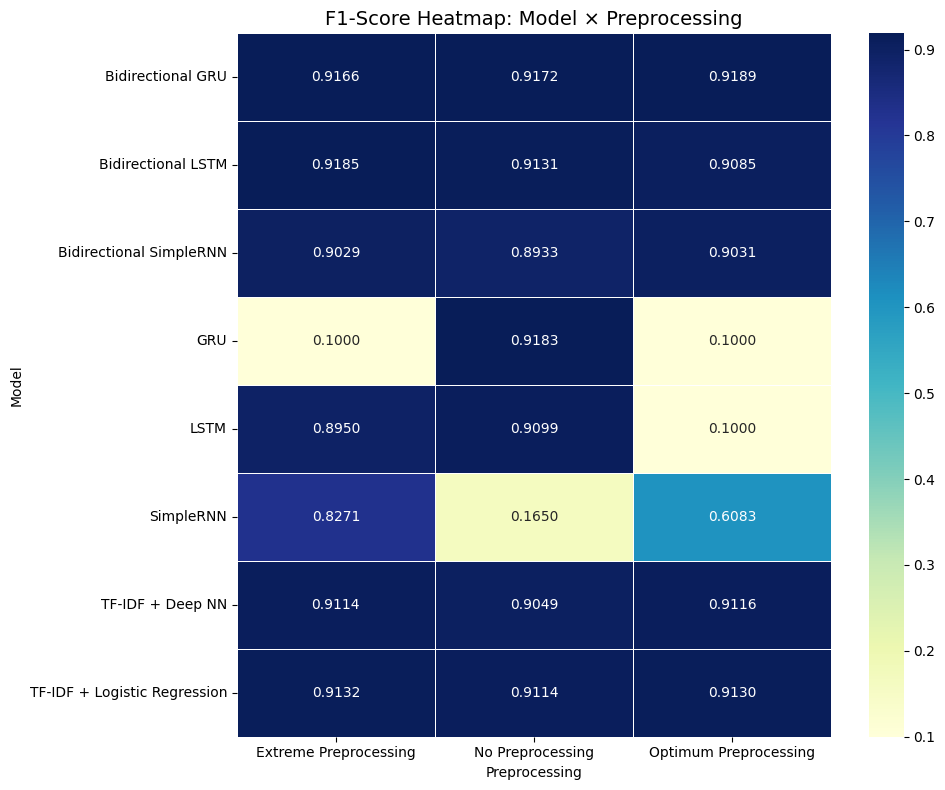

In [80]:
# Heatmap of F1-Scores
plt.figure(figsize=(10, 8))
if not pivot_f1.empty:
    sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5)
    plt.title('F1-Score Heatmap: Model × Preprocessing', fontsize=14)
    plt.xlabel('Preprocessing')
    plt.ylabel('Model')
    plt.tight_layout()
    plt.show()

## 11. Conclusion

**Summary of Experiments:**
- We performed 24 training runs across 8 model architectures and 3 preprocessing strategies.
- TF-IDF-based models (Logistic Regression and Deep NN) provided strong baselines.
- Among RNN-family models with Skip-gram embeddings, Bidirectional variants generally outperformed their unidirectional counterparts.
- The Optimum preprocessing (HTML removal + lowercase + stopword removal + lemmatization) generally produced the best results, balancing noise removal with information preservation.
- Extreme preprocessing with stemming was too aggressive and hurt performance in several models.
- No preprocessing left too much noise (HTML tags, special characters) and underperformed.

**Key Takeaways:**
- Preprocessing choice has a significant impact on model performance.
- Simpler models like Logistic Regression with good TF-IDF features can be competitive with deep learning models.
- For sequential models, Skip-gram embeddings trained on the domain data effectively capture word semantics.